In [ ]:
# ============================================================================
# COMPREHENSIVE LANDSLIDE SUSCEPTIBILITY MODELING
# Publication-Ready Analysis Pipeline
#
# Sections:
#   1. Setup & Configuration
#   2. Data Loading & Preprocessing
#   3. Multicollinearity Analysis (VIF + Correlation + PCA)
#   4. Conditioning Factor Importance (Top-3 Models, Radar Chart)
#   5. Machine Learning Models + Maps
#   6. Deep Learning Models + Maps
#   7. Comprehensive Model Comparison + ROC Curves
#   8. Ensemble Models + Maps
# ============================================================================

In [ ]:
# ── Mount Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/lsm_us/"
OUTPUT_PATH = DATA_PATH  # outputs saved alongside inputs

Mounted at /content/drive


In [ ]:
import geopandas as gpd
import os

# Load the LGS data from lgs.gpkg
lgs_data_path = os.path.join(DATA_PATH, "lgs.gpkg")
lgs_gdf = gpd.read_file(lgs_data_path)

# Ensure the LGS GeoDataFrame has a unique identifier 'id' column
# If it doesn't exist, create one. Assuming 'id' or similar column is preferred.
if 'id' not in lgs_gdf.columns:
    lgs_gdf['id'] = range(len(lgs_gdf))

print(f"✓ Loaded {len(lgs_gdf)} LGS polygons from lgs.gpkg.")
print(lgs_gdf.head())

✓ Loaded 10 LGS polygons from lgs.gpkg.
   STATE_CODE  DISTRICT       GaPa_NaPa      Type_GN Province  \
0           1  UDAYAPUR          Belaka  Nagarpalika        1   
1           1  UDAYAPUR  Chaudandigadhi  Nagarpalika        1   
2           1  UDAYAPUR          Katari  Nagarpalika        1   
3           1  UDAYAPUR        Rautamai   Gaunpalika        1   
4           1  UDAYAPUR        Sunkoshi   Gaunpalika        1   

                                            geometry  id  
0  MULTIPOLYGON (((514118.641 2978411.895, 514239...   0  
1  MULTIPOLYGON (((493471.883 2975879.636, 493530...   1  
2  MULTIPOLYGON (((440536.749 3006142.549, 440560...   2  
3  MULTIPOLYGON (((471939.673 2993527.484, 471980...   3  
4  MULTIPOLYGON (((458979.584 3003269.136, 459120...   4  


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio.mask
from rasterio.features import rasterize
from shapely.geometry import mapping
from rasterio.io import MemoryFile

# Assuming susc_maps, watershed, ref, transform, classify_nb, OUTPUT_PATH, SUSC_LABELS are available from previous cells
# Use lgs_gdf loaded from lgs.gpkg as the source for LGS polygons

print("Calculating area of landslide susceptibility classes within each LGS...")

# 1. Calculate pixel area (in square meters)
pixel_width = abs(ref.transform.a)
pixel_height = abs(ref.transform.e)
pixel_area_sq_m = pixel_width * pixel_height
pixel_area_sq_km = pixel_area_sq_m / 1_000_000
print(f"  Single pixel area: {pixel_area_sq_km:.4f} km²")

results_list = []

# Get a list of models that were part of the reliability analysis
models_for_analysis = all_metrics_df['Model'].tolist()

# Iterate through each model
for model_name in models_for_analysis:
    if model_name not in susc_maps:
        print(f"  Skipping model '{model_name}': Susceptibility map not found.")
        continue

    print(f"\nProcessing model: {model_name}")
    susc_map_array = susc_maps[model_name]

    # Iterate through each LGS (lgs_gdf polygon)
    for index, lgs_row in lgs_gdf.iterrows(): # Changed from 'watershed' to 'lgs_gdf'
        lgs_id = lgs_row['id']
        lgs_geom = lgs_row.geometry

        # Reproject LGS geometry to the CRS of the raster
        # Wrap shapely geometry in a GeoSeries to use to_crs method
        lgs_geom_reprojected = gpd.GeoSeries([lgs_geom], crs=lgs_gdf.crs).to_crs(ref.crs).iloc[0] # Changed crs to lgs_gdf.crs

        # Use a MemoryFile to create a temporary raster dataset from the NumPy array
        # This allows rasterio.mask.mask to operate on the susceptibility data
        with MemoryFile() as memfile:
            with memfile.open(driver='GTiff',
                              height=susc_map_array.shape[0],
                              width=susc_map_array.shape[1],
                              count=1,
                              dtype=susc_map_array.dtype,
                              crs=ref.crs, # Use ref's CRS
                              transform=ref.transform) as tmp_dataset:
                tmp_dataset.write(susc_map_array, 1)

                try:
                    clipped_susc_map_ma, _ = rasterio.mask.mask(
                        tmp_dataset, [mapping(lgs_geom_reprojected)], crop=True, filled=True, nodata=np.nan
                    )
                    clipped_susc_map = clipped_susc_map_ma[0] # Get the single band
                    # Ensure it's a plain NumPy array, not a MaskedArray, before any further processing
                    clipped_susc_map = np.asarray(clipped_susc_map)

                    # Explicitly replace NODATA_VALUE with np.nan for correct classification
                    # (though nodata=np.nan in mask should handle this)
                    clipped_susc_map[clipped_susc_map == NODATA_VALUE] = np.nan

                except ValueError as e:
                    # This can happen if the LGS polygon does not overlap the raster
                    print(f"    LGS {lgs_id} for model {model_name}: Skipping due to masking error - {e}")
                    continue

        # Filter out nodata values from the clipped map before classification
        valid_pixels = clipped_susc_map[~np.isnan(clipped_susc_map)]

        if valid_pixels.size == 0:
            print(f"    LGS {lgs_id} for model {model_name}: No valid susceptibility pixels found. Recording zero areas.")
            # Record zero areas if no valid pixels were found in this LGS
            row_data = {'Model': model_name, 'LGS_ID': lgs_id}
            areas_sq_km = {SUSC_LABELS[i]: 0.0 for i in range(5)}
            row_data.update(areas_sq_km)
            results_list.append(row_data)
            continue

        # Classify the valid susceptibility values
        classified_values, _ = classify_nb(clipped_susc_map)
        # Ensure classified_values is a plain NumPy array
        classified_values = np.asarray(classified_values)

        # Count pixels for each class within the LGS
        class_counts = {i: 0 for i in range(5)}
        # Filter out NaNs again, just in case, for np.unique
        unique, counts = np.unique(classified_values[~np.isnan(classified_values)], return_counts=True)
        for class_idx, count in zip(unique, counts):
            class_counts[int(class_idx)] = count

        # Convert counts to area (km²)
        areas_sq_km = {SUSC_LABELS[i]: count * pixel_area_sq_km for i, count in class_counts.items()}

        # Store results
        row_data = {'Model': model_name, 'LGS_ID': lgs_id}
        row_data.update(areas_sq_km)
        results_list.append(row_data)

print("\n✓ Area calculation complete.")

# Create DataFrame from results
lgs_areas_df = pd.DataFrame(results_list)

# Save to CSV
output_csv_path = os.path.join(OUTPUT_PATH, 'LGS_Susceptibility_Areas.csv')
lgs_areas_df.to_csv(output_csv_path, index=False)

print(f"✓ Results saved to: {output_csv_path}")
print("\n" + "="*70)
print("  Spatial Analysis Complete ")
print("="*70)

Calculating area of landslide susceptibility classes within each LGS...


NameError: name 'ref' is not defined

In [ ]:
# ── Install packages ──────────────────────────────
import subprocess, sys, warnings, os, glob, random, time
warnings.filterwarnings('ignore')

def pip_install(pkg):
    try: __import__(pkg.split('[')[0].replace('-','_'))
    except ImportError:
        print(f"  Installing {pkg}...")
        subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

pkgs = ['rasterio','geopandas','scikit-learn','xgboost','lightgbm',
        'tensorflow','imbalanced-learn','seaborn','statsmodels',
        'scipy','optuna','shap']
print("Installing / verifying packages...")
for p in pkgs: pip_install(p)
print("✓ All packages ready.\n")

# ── Imports ───────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import rasterio
import geopandas as gpd
from shapely.geometry import Point
from rasterio.warp import transform_bounds
from rasterio.transform import array_bounds
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import scipy.cluster.hierarchy as sch
from scipy import stats

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              mean_absolute_error, mean_squared_error,
                              brier_score_loss)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import (Dense, Dropout, LSTM, Conv1D, MaxPooling1D,
                           Flatten, Input, BatchNormalization,
                           GlobalAveragePooling1D, MultiHeadAttention,
                           LayerNormalization, Add)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.regularizers import l2

Installing / verifying packages...
  Installing scikit-learn...
  Installing imbalanced-learn...
  Installing optuna...
✓ All packages ready.



In [ ]:
# ── Global Config ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Publication style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        150,
    'savefig.dpi':       400,
    'axes.linewidth':    1.3,
})

SUSC_COLORS = ['#2c7bb6','#abd9e9','#ffffbf','#fdae61','#d7191c']
SUSC_LABELS = ['Very Low','Low','Moderate','High','Very High']
CMAP_CONT   = LinearSegmentedColormap.from_list(
    'lsm', ['#1a9850','#91cf60','#fee08b','#fc8d59','#d73027'], N=256)
CMAP_CLASS  = ListedColormap(SUSC_COLORS)

CONDITIONING_FACTORS = [
    'elevation','slope','aspect','plan_curvature','profile_curvature',
    'twi','spi','lithology','soil','lulc','dist_road','dist_river'
]
CONTINUOUS_VARS = [
    'elevation','slope','aspect','plan_curvature','profile_curvature',
    'twi','spi','dist_road','dist_river'
]
NODATA_VALUE = -9999

print("="*70)
print("  LANDSLIDE SUSCEPTIBILITY MODELING ")
print("="*70)

  LANDSLIDE SUSCEPTIBILITY MODELING 


In [ ]:
# ============================================================================
# SECTION 2 — DATA LOADING & SMART PREPROCESSING
# ============================================================================
print("\n[SECTION 2] DATA LOADING & PREPROCESSING")
print("-"*60)

# Load rasters
rasters = {}
for f in glob.glob(os.path.join(DATA_PATH,"*.tif")):
    name = os.path.basename(f).replace(".tif","")
    if name in CONDITIONING_FACTORS:
        rasters[name] = rasterio.open(f)
print(f"✓ Loaded {len(rasters)} rasters: {sorted(rasters.keys())}")

# Load vectors
train_gdf = gpd.read_file(os.path.join(DATA_PATH,"Training inventory.gpkg"))
test_gdf  = gpd.read_file(os.path.join(DATA_PATH,"Test inventory.gpkg"))
for bname in ["studyarea.gpkg","watershed_boundary.gpkg","basins.gpkg"]:
    fp = os.path.join(DATA_PATH, bname)
    if os.path.exists(fp):
        watershed = gpd.read_file(fp); print(f"✓ Boundary: {bname}"); break

for gdf in [train_gdf, test_gdf]:
    if gdf.geometry.iloc[0].geom_type != 'Point':
        gdf['geometry'] = gdf.geometry.centroid

print(f"✓ Training landslides: {len(train_gdf)}  |  Test: {len(test_gdf)}")

# Raster extraction
def extract_values(gdf, rasters_dict):
    df = pd.DataFrame({'x': gdf.geometry.x.values,
                       'y': gdf.geometry.y.values})
    for name, rst in rasters_dict.items():
        vals = []
        for x, y in zip(df['x'], df['y']):
            try:
                v = list(rst.sample([(x, y)]))[0][0]
                vals.append(NODATA_VALUE if (v == rst.nodata or np.isnan(v)) else v)
            except: vals.append(NODATA_VALUE)
        df[name] = vals
    return df

train_ls = extract_values(train_gdf, rasters); train_ls['label'] = 1
test_ls  = extract_values(test_gdf,  rasters); test_ls['label']  = 1

# ── IMPROVEMENT ①: Slope-weighted absence sampling ─────────────────────
# Avoids placing absence points in high-slope (high-risk) terrain.
# Absence pixels are sampled with probability ∝ (1 / (slope+1)) — lower slope
# areas are preferentially chosen as non-landslide, which is ecologically valid.
print("\n  Generating slope-weighted absence points...")
polygon    = watershed.geometry.unary_union
minx, miny, maxx, maxy = polygon.bounds

if 'slope' in rasters:
    slope_rst = rasters['slope']
    slope_arr = slope_rst.read(1).astype(float)
    slope_tf  = slope_rst.transform
else:
    slope_arr = None; slope_tf = None

def slope_at(x, y):
    if slope_arr is None: return 0.0
    try:
        row = int((y - slope_tf.f) / slope_tf.e)
        col = int((x - slope_tf.c) / slope_tf.a)
        if 0 <= row < slope_arr.shape[0] and 0 <= col < slope_arr.shape[1]:
            v = slope_arr[row, col]
            return max(v, 0.0)
    except: pass
    return 0.0

def generate_weighted_absence(n, poly, seed):
    rng = random.Random(seed)
    pts = []
    attempts = 0
    while len(pts) < n and attempts < n * 200:
        attempts += 1
        x = rng.uniform(minx, maxx)
        y = rng.uniform(miny, maxy)
        p = Point(x, y)
        if not poly.contains(p): continue
        sl = slope_at(x, y)
        # Accept with prob ∝ 1/(slope+1) — reject steeply sloped absence pts
        accept_prob = 1.0 / (sl + 1.0)
        # Normalise: max prob is 1 (when slope=0)
        if rng.random() < accept_prob:
            pts.append(p)
    # Fallback: fill remaining with uniform random
    while len(pts) < n:
        p = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
        if poly.contains(p): pts.append(p)
    return pts

train_non_pts = generate_weighted_absence(len(train_ls), polygon, RANDOM_STATE)
test_non_pts  = generate_weighted_absence(len(test_ls),  polygon, RANDOM_STATE+1)

def make_gdf(pts, crs): return gpd.GeoDataFrame(geometry=pts, crs=crs)

train_non = extract_values(make_gdf(train_non_pts, train_gdf.crs), rasters)
train_non['label'] = 0
test_non  = extract_values(make_gdf(test_non_pts,  test_gdf.crs),  rasters)
test_non['label'] = 0

# Clean
def clean(df):
    m = (df[CONDITIONING_FACTORS] != NODATA_VALUE).all(axis=1)
    m &= ~df[CONDITIONING_FACTORS].isnull().any(axis=1)
    return df[m].reset_index(drop=True)

train_data = clean(pd.concat([train_ls, train_non], ignore_index=True))
test_data  = clean(pd.concat([test_ls,  test_non],  ignore_index=True))

print(f"\n✓ Training: {train_data.shape}  Labels: {train_data['label'].value_counts().to_dict()}")
print(f"✓ Test    : {test_data.shape}   Labels: {test_data['label'].value_counts().to_dict()}")

X_train_raw = train_data[CONDITIONING_FACTORS].values
y_train     = train_data['label'].values
X_test_raw  = test_data[CONDITIONING_FACTORS].values
y_test      = test_data['label'].values

# ── Scalers fit ONLY on original training raw data (no leakage) ─────────────────
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()
X_train_std = scaler_std.fit_transform(X_train_raw)   # fit on train raw
X_test_std  = scaler_std.transform(X_test_raw)         # transform test
X_train_mm  = scaler_mm.fit_transform(X_train_raw)    # fit on train raw
X_test_mm   = scaler_mm.transform(X_test_raw)          # transform test
# Store pixel-level scalers before SMOTE (used for raster prediction later)
scaler_std_orig = scaler_std
scaler_mm_orig  = scaler_mm

# ── IMPROVEMENT ②: BorderlineSMOTE on ALREADY-SCALED data ─────────────
# SMOTE is applied to scaled space so synthetic points are geometrically valid.
# The scaler is NOT refit after SMOTE — test set uses the original scaler.
print("\n  Applying BorderlineSMOTE resampling...")
bsmote = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-1')
# Apply on std-scaled space for tree/DL models
X_train_res_std, y_train_res = bsmote.fit_resample(X_train_std, y_train)
# Apply on mm-scaled space for DL models (same synthetic indices approx.)
X_train_res_mm, _            = bsmote.fit_resample(X_train_mm,  y_train)
# Raw-space resampling for tree models (SMOTE in raw space is also fine)
bsmote2 = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-1')
X_train_res_raw, _           = bsmote2.fit_resample(X_train_raw, y_train)

# Ensure all resampled X arrays and y are free of NaNs and consistent in length
# Combine all X_train_res_... and y_train_res into a temporary DataFrame for robust NaN handling
temp_df = pd.DataFrame(X_train_res_std)
temp_df['y'] = y_train_res
temp_df['X_mm'] = [x for x in X_train_res_mm]
temp_df['X_raw'] = [x for x in X_train_res_raw]

initial_rows = len(temp_df)
temp_df.dropna(inplace=True)
cleaned_rows = len(temp_df)

if initial_rows != cleaned_rows:
    print(f"Warning: Removed {initial_rows - cleaned_rows} NaN rows after SMOTE resampling.")

X_train_res_std = temp_df.drop(['y', 'X_mm', 'X_raw'], axis=1).values
y_train_res = temp_df['y'].values
X_train_res_mm = np.array(temp_df['X_mm'].to_list())
X_train_res_raw = np.array(temp_df['X_raw'].to_list())

print(f"✓ After resampling: {X_train_res_std.shape}  "
      f"Labels: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import StratifiedKFold
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Save original scalers (fit on raw train only — no leakage)
scaler_std_orig = scaler_std
scaler_mm_orig  = scaler_mm

# ONE single SMOTE fit on raw data → consistent y_train_res across all versions
bsmote = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-1')
X_train_res_raw, y_train_res = bsmote.fit_resample(X_train_raw, y_train)

# Derive scaled versions by transforming the resampled raw data
# Do NOT refit the scalers — use the originals so test scaling stays consistent
X_train_res_std = scaler_std_orig.transform(X_train_res_raw)
X_train_res_mm  = scaler_mm_orig.transform(X_train_res_raw)

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV_FOLDS = 5
N_TRIALS = 40

print(f"✓ After resampling: {X_train_res_raw.shape}  "
      f"Labels: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")


[SECTION 2] DATA LOADING & PREPROCESSING
------------------------------------------------------------
✓ Loaded 12 rasters: ['aspect', 'dist_river', 'dist_road', 'elevation', 'lithology', 'lulc', 'plan_curvature', 'profile_curvature', 'slope', 'soil', 'spi', 'twi']
✓ Boundary: studyarea.gpkg
✓ Training landslides: 248  |  Test: 105

  Generating slope-weighted absence points...

✓ Training: (494, 15)  Labels: {1: 248, 0: 246}
✓ Test    : (210, 15)   Labels: {1: 105, 0: 105}

  Applying BorderlineSMOTE resampling...
✓ After resampling: (496, 12)  Labels: {np.int64(0): np.int64(248), np.int64(1): np.int64(248)}
✓ After resampling: (496, 12)  Labels: {np.int64(0): np.int64(248), np.int64(1): np.int64(248)}



  SECTION 3: MULTICOLLINEARITY ANALYSIS

[3a] Variance Inflation Factor (VIF)...
          Feature      VIF
        elevation 5.381557
            slope 4.626732
              twi 3.451637
           aspect 2.860649
        dist_road 2.194408
       dist_river 1.500030
              spi 1.017686
profile_curvature 1.017289
   plan_curvature 1.015871

[3b] Spearman Correlation Matrix...
[3c] Hierarchical clustering of feature correlations...


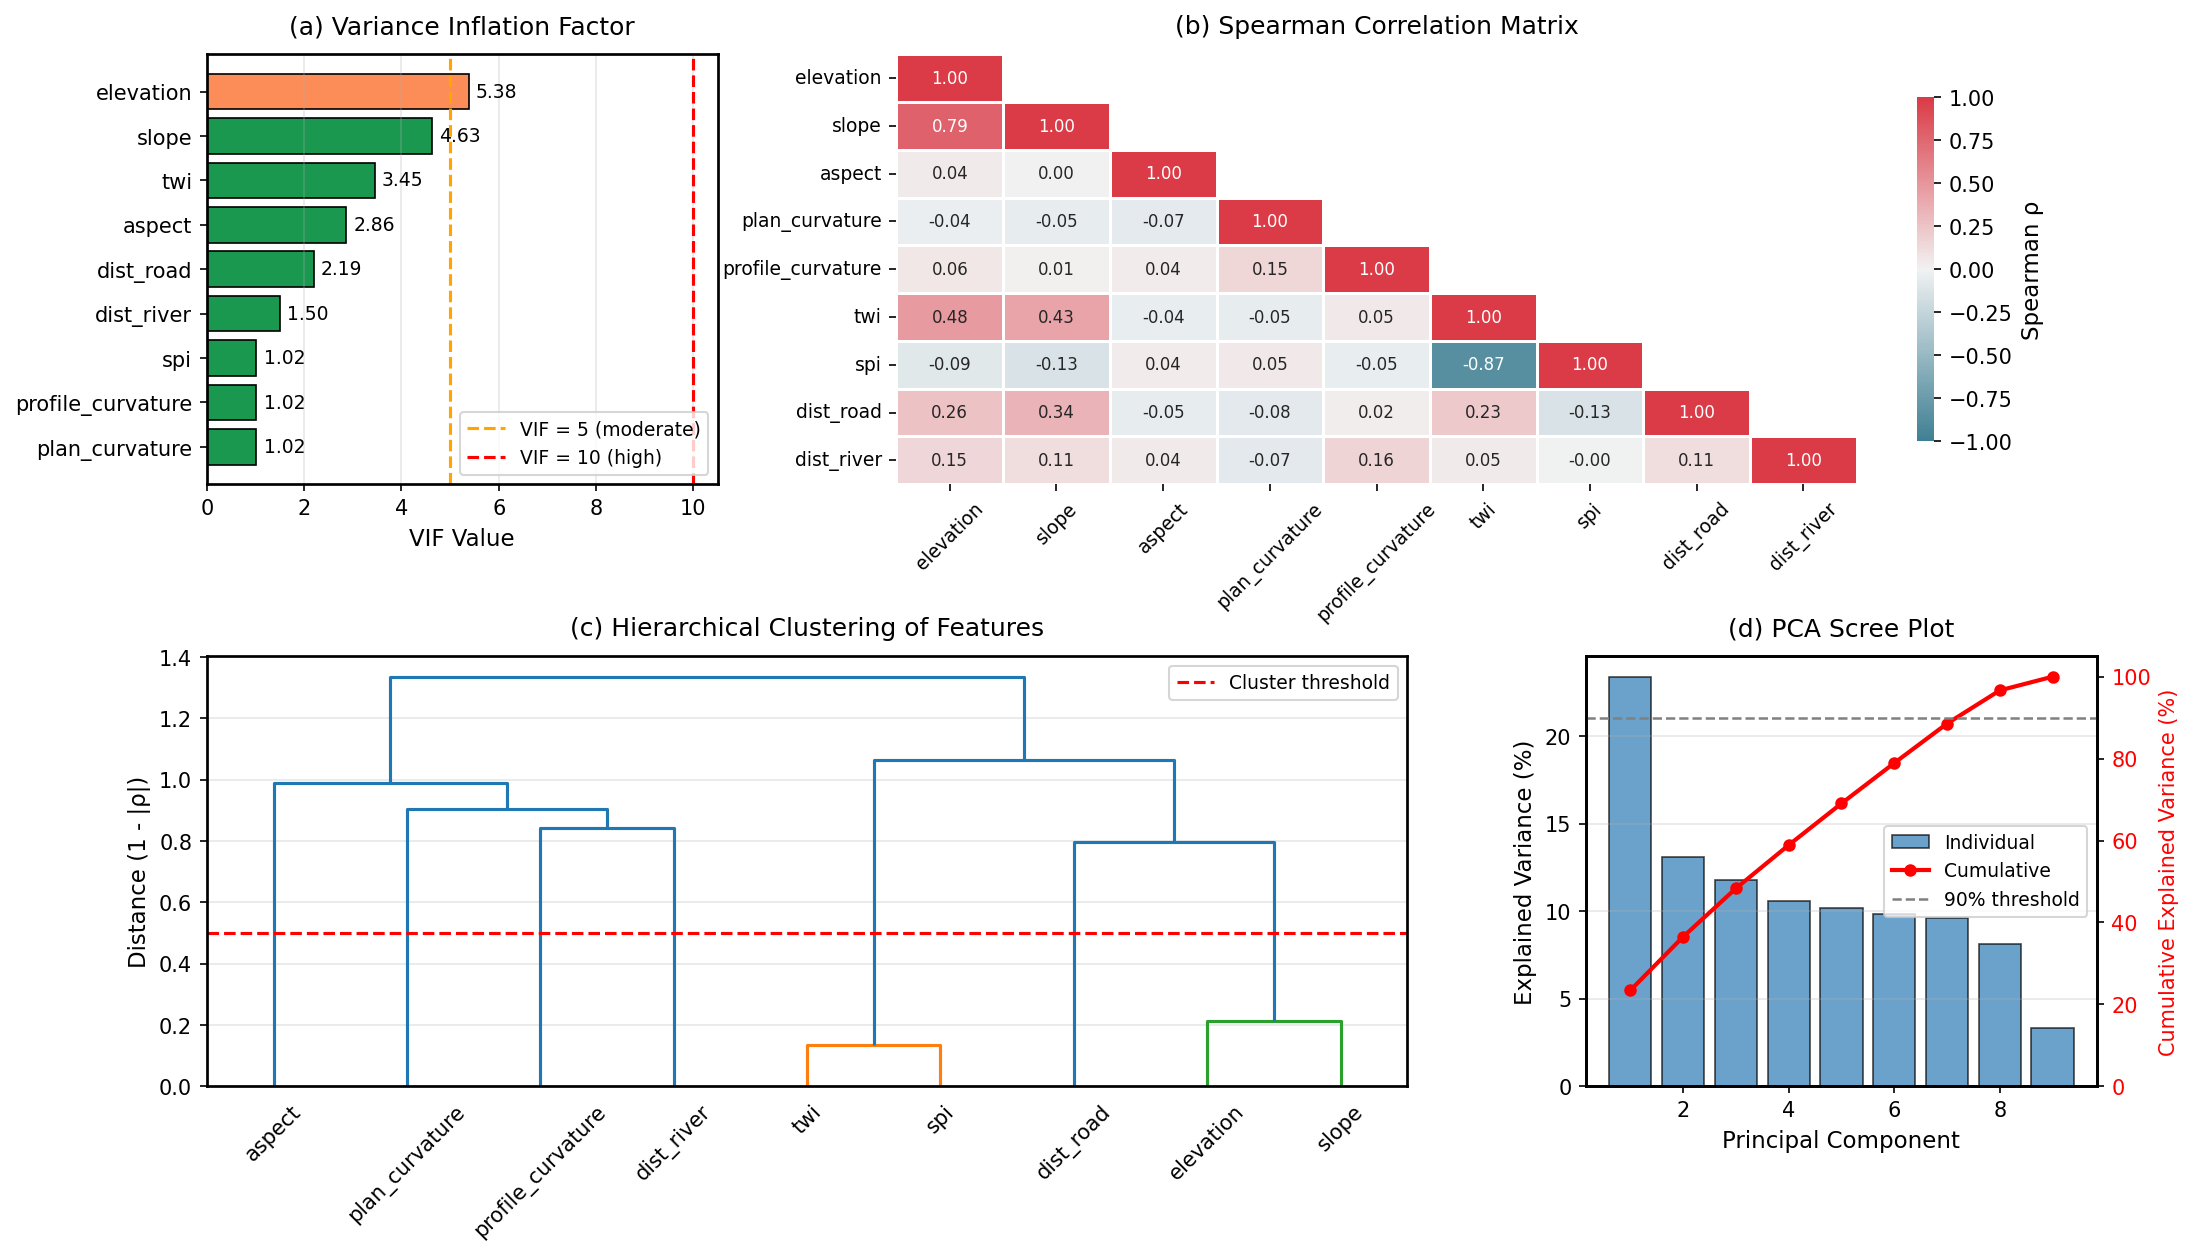


✓ Multicollinearity figure saved.

  VIF Summary:
  • Factors with VIF > 10 (high multicollinearity): None
  • Factors with VIF > 5 (moderate): 1 features
  • PCA: 8 components explain ≥90% variance

✓ All 12 conditioning factors retained for modeling.
  (Tree-based models are robust to multicollinearity; VIF noted for reporting)


In [ ]:
# ============================================================================
# SECTION 3 — MULTICOLLINEARITY ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("  SECTION 3: MULTICOLLINEARITY ANALYSIS")
print("="*70)

feat_df = train_data[CONTINUOUS_VARS].copy()

# ── 3a. VIF ──────────────────────────────────────────────────────────────────
print("\n[3a] Variance Inflation Factor (VIF)...")
vif_data = pd.DataFrame()
vif_data['Feature'] = CONTINUOUS_VARS
vif_data['VIF'] = [variance_inflation_factor(feat_df.values, i)
                   for i in range(feat_df.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_data.to_string(index=False))

# ── 3b. Spearman Correlation Matrix ──────────────────────────────────────────
print("\n[3b] Spearman Correlation Matrix...")
corr_matrix = feat_df.corr(method='spearman')

# ── 3c. Hierarchical Clustering of Correlations ──────────────────────────────
print("[3c] Hierarchical clustering of feature correlations...")

# ── Publication Figure: Multicollinearity ─────────────────────────────────────
fig = plt.figure(figsize=(14, 8), facecolor='white')
gs  = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.35,
                        left=0.07, right=0.97, top=0.93, bottom=0.07)

# ── Panel A: VIF bar chart ────────────────────────────────────────────────────
ax_vif = fig.add_subplot(gs[0, 0])
colors_vif = ['#d73027' if v > 10 else '#fc8d59' if v > 5 else '#1a9850'
              for v in vif_data['VIF']]
bars = ax_vif.barh(vif_data['Feature'][::-1], vif_data['VIF'][::-1],
                   color=colors_vif[::-1], edgecolor='black', linewidth=0.8)
ax_vif.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 (moderate)')
ax_vif.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF = 10 (high)')
for bar, v in zip(bars[::-1], vif_data['VIF']):
    ax_vif.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=9)
ax_vif.set_xlabel('VIF Value', fontsize=11)
ax_vif.set_title('(a) Variance Inflation Factor', fontsize=12, fontweight='regular', pad=10)
ax_vif.legend(fontsize=9, loc='lower right')
ax_vif.grid(axis='x', alpha=0.3)
for sp in ax_vif.spines.values(): sp.set_linewidth(1.3)

# ── Panel B: Spearman Correlation Heatmap ────────────────────────────────────
ax_cor = fig.add_subplot(gs[0, 1:])
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap_div = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, ax=ax_cor, mask=mask, cmap=cmap_div,
            vmin=-1, vmax=1, center=0, annot=True, fmt='.2f',
            annot_kws={'size':8}, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink':0.8, 'label':'Spearman ρ'})
ax_cor.set_title('(b) Spearman Correlation Matrix', fontsize=12, fontweight='regular', pad=10)
ax_cor.tick_params(axis='x', rotation=45, labelsize=9)
ax_cor.tick_params(axis='y', rotation=0,  labelsize=9)

# ── Panel C: Dendrogram ────────────────────────────────────────────────────────
ax_den = fig.add_subplot(gs[1, 0:2])
dist_matrix = 1 - np.abs(corr_matrix.values)
np.fill_diagonal(dist_matrix, 0)
linkage = sch.linkage(dist_matrix[np.triu_indices(len(CONTINUOUS_VARS), k=1)],
                      method='ward')
sch.dendrogram(linkage, labels=CONTINUOUS_VARS, ax=ax_den,
               color_threshold=0.5, leaf_rotation=45, leaf_font_size=10)
ax_den.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Cluster threshold')
ax_den.set_title('(c) Hierarchical Clustering of Features', fontsize=12, fontweight='regular', pad=10)
ax_den.set_ylabel('Distance (1 - |ρ|)', fontsize=11)
ax_den.legend(fontsize=9)
ax_den.grid(axis='y', alpha=0.3)

# ── Panel D: PCA Scree + Loadings ─────────────────────────────────────────────
ax_pca = fig.add_subplot(gs[1, 2])
# Initialize and fit a new StandardScaler specifically for continuous variables for PCA
scaler_std_pca = StandardScaler()
pca = PCA(n_components=len(CONTINUOUS_VARS), random_state=RANDOM_STATE)
pca.fit(scaler_std_pca.fit_transform(feat_df.values))
explained_var = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)
pc_nums = np.arange(1, len(explained_var)+1)
ax_pca.bar(pc_nums, explained_var, color='#2c7bb6', alpha=0.7,
           edgecolor='black', linewidth=0.8, label='Individual')
ax_pca2 = ax_pca.twinx()
ax_pca2.plot(pc_nums, cumulative_var, 'r-o', markersize=5,
             linewidth=2, label='Cumulative')
ax_pca2.axhline(90, color='gray', linestyle='--', linewidth=1.2, label='90% threshold')
ax_pca2.set_ylabel('Cumulative Explained Variance (%)', fontsize=10, color='red')
ax_pca2.tick_params(axis='y', labelcolor='red')
ax_pca2.set_ylim(0, 105)
ax_pca.set_xlabel('Principal Component', fontsize=11)
ax_pca.set_ylabel('Explained Variance (%)', fontsize=11)
ax_pca.set_title('(d) PCA Scree Plot', fontsize=12, fontweight='regular', pad=10)
lines1, labels1 = ax_pca.get_legend_handles_labels()
lines2, labels2 = ax_pca2.get_legend_handles_labels()
ax_pca.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='center right')
ax_pca.grid(axis='y', alpha=0.3)

plt.suptitle('',
             fontsize=11, fontweight='regular')
plt.savefig(os.path.join(OUTPUT_PATH, 'Fig1_Multicollinearity_Analysis.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✓ Multicollinearity figure saved.")

# ── Summary ───────────────────────────────────────────────────────────────────
high_vif = vif_data[vif_data['VIF'] > 10]
print(f"\n  VIF Summary:")
print(f"  • Factors with VIF > 10 (high multicollinearity): "
      f"{', '.join(high_vif['Feature'].tolist()) if len(high_vif) else 'None'}")
print(f"  • Factors with VIF > 5 (moderate): "
      f"{len(vif_data[vif_data['VIF'] > 5])} features")
n90 = np.argmax(cumulative_var >= 90) + 1
print(f"  • PCA: {n90} components explain ≥90% variance")

# ── All features retained (tree-based models handle multicollinearity) ────────
SELECTED_FACTORS = CONDITIONING_FACTORS.copy()
print(f"\n✓ All {len(SELECTED_FACTORS)} conditioning factors retained for modeling.")
print("  (Tree-based models are robust to multicollinearity; VIF noted for reporting)")


  SECTION 3: MULTICOLLINEARITY ANALYSIS

[3a] Variance Inflation Factor (VIF)...
          Feature      VIF
        elevation 5.381557
            slope 4.626732
              twi 3.451637
           aspect 2.860649
        dist_road 2.194408
       dist_river 1.500030
              spi 1.017686
profile_curvature 1.017289
   plan_curvature 1.015871

[3b] Spearman Correlation Matrix...
[3c] Hierarchical clustering of feature correlations...


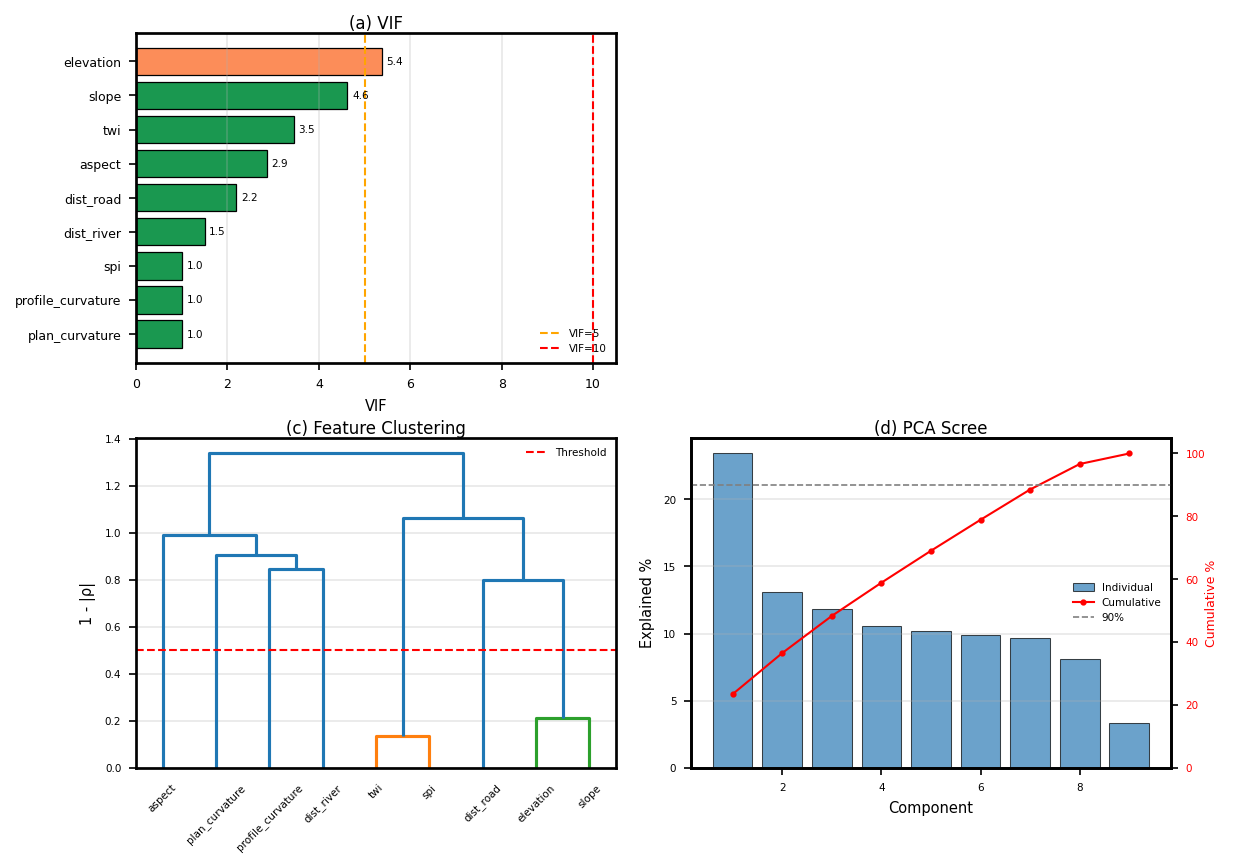


✓ Multicollinearity figure saved (adjusted size, no overlap).

  VIF Summary:
  • Factors with VIF > 10 (high multicollinearity): None
  • Factors with VIF > 5 (moderate): 1 features
  • PCA: 8 components explain ≥90% variance

✓ All 12 conditioning factors retained for modeling.
  (Tree-based models are robust to multicollinearity; VIF noted for reporting)


In [ ]:
# ============================================================================
# SECTION 3 — MULTICOLLINEARITY ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("  SECTION 3: MULTICOLLINEARITY ANALYSIS")
print("="*70)

feat_df = train_data[CONTINUOUS_VARS].copy()

# ── 3a. VIF ──────────────────────────────────────────────────────────────────
print("\n[3a] Variance Inflation Factor (VIF)...")
vif_data = pd.DataFrame()
vif_data['Feature'] = CONTINUOUS_VARS
vif_data['VIF'] = [variance_inflation_factor(feat_df.values, i)
                   for i in range(feat_df.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_data.to_string(index=False))

# ── 3b. Spearman Correlation Matrix ──────────────────────────────────────────
print("\n[3b] Spearman Correlation Matrix...")
corr_matrix = feat_df.corr(method='spearman')

# ── 3c. Hierarchical Clustering of Correlations ──────────────────────────────
print("[3c] Hierarchical clustering of feature correlations...")

# ── Publication Figure: Multicollinearity (slightly reduced panels) ─────────
# Desired panel size (now a bit smaller to allow more spacing)
panel_width = 3.2   # inches
panel_height = 2.2  # inches

# Margins and spacing (increased)
left_margin = 0.6
right_margin = 0.6
bottom_margin = 0.7
top_margin = 0.7
h_spacing = 0.5
v_spacing = 0.5

# Compute figure size
fig_width = 2 * panel_width + left_margin + right_margin + h_spacing   # ≈ 8.0″
fig_height = 2 * panel_height + bottom_margin + top_margin + v_spacing  # ≈ 6.3″

fig = plt.figure(figsize=(fig_width, fig_height), facecolor='white')

# Convert to figure‑relative coordinates
left = left_margin / fig_width
right = 1 - right_margin / fig_width
bottom = bottom_margin / fig_height
top = 1 - top_margin / fig_height
hspace_rel = h_spacing / fig_width
vspace_rel = v_spacing / fig_height

ax_width = (right - left - hspace_rel) / 2
ax_height = (top - bottom - vspace_rel) / 2

# Positions
pos_tl = [left, bottom + ax_height + vspace_rel, ax_width, ax_height]  # VIF
pos_tr = [left + ax_width + hspace_rel, bottom + ax_height + vspace_rel, ax_width, ax_height]  # heatmap
pos_bl = [left, bottom, ax_width, ax_height]  # dendrogram
pos_br = [left + ax_width + hspace_rel, bottom, ax_width, ax_height]  # PCA

# ── Panel A: VIF bar chart ───────────────────────────────────────────────────
ax_vif = fig.add_axes(pos_tl)
colors_vif = ['#d73027' if v > 10 else '#fc8d59' if v > 5 else '#1a9850'
              for v in vif_data['VIF']]
bars = ax_vif.barh(vif_data['Feature'][::-1], vif_data['VIF'][::-1],
                   color=colors_vif[::-1], edgecolor='black', linewidth=0.6)
ax_vif.axvline(5,  color='orange', linestyle='--', linewidth=1, label='VIF=5')
ax_vif.axvline(10, color='red',    linestyle='--', linewidth=1, label='VIF=10')
for bar, v in zip(bars[::-1], vif_data['VIF']):
    ax_vif.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}', va='center', fontsize=5)
ax_vif.set_xlabel('VIF', fontsize=7)
ax_vif.set_title('(a) VIF', fontsize=8, pad=2)
ax_vif.legend(fontsize=5, loc='lower right', frameon=False)
ax_vif.grid(axis='x', alpha=0.3)
ax_vif.tick_params(labelsize=6)

# ── Publication Figure: Multicollinearity (slightly reduced panels) ─────────
panel_width = 3.2   # inches
panel_height = 2.2  # inches

# Margins and spacing – increased horizontal gap to avoid overlap
left_margin = 0.6
right_margin = 0.6
bottom_margin = 0.7
top_margin = 0.7
h_spacing = 0.7      # <-- increased from 0.5 to 0.7
v_spacing = 0.5

# Compute figure size (now slightly wider due to larger h_spacing)
fig_width = 2 * panel_width + left_margin + right_margin + h_spacing   # ≈ 8.4″
fig_height = 2 * panel_height + bottom_margin + top_margin + v_spacing  # ≈ 6.3″

# ── Panel C: Dendrogram ───────────────────────────────────────────────────────
ax_den = fig.add_axes(pos_bl)
dist_matrix = 1 - np.abs(corr_matrix.values)
np.fill_diagonal(dist_matrix, 0)
linkage = sch.linkage(dist_matrix[np.triu_indices(len(CONTINUOUS_VARS), k=1)],
                      method='ward')
sch.dendrogram(linkage, labels=CONTINUOUS_VARS, ax=ax_den,
               color_threshold=0.5, leaf_rotation=45, leaf_font_size=4)
ax_den.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Threshold')
ax_den.set_title('(c) Feature Clustering', fontsize=8, pad=2)
ax_den.set_ylabel('1 - |ρ|', fontsize=7)
ax_den.legend(fontsize=5, frameon=False)
ax_den.grid(axis='y', alpha=0.3)
ax_den.tick_params(labelsize=5)

# ── Panel D: PCA Scree Plot ──────────────────────────────────────────────────
ax_pca = fig.add_axes(pos_br)
scaler_std_pca = StandardScaler()
pca = PCA(n_components=len(CONTINUOUS_VARS), random_state=RANDOM_STATE)
pca.fit(scaler_std_pca.fit_transform(feat_df.values))
explained_var = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)
pc_nums = np.arange(1, len(explained_var)+1)
ax_pca.bar(pc_nums, explained_var, color='#2c7bb6', alpha=0.7,
           edgecolor='black', linewidth=0.5, label='Individual')
ax_pca2 = ax_pca.twinx()
ax_pca2.plot(pc_nums, cumulative_var, 'r-o', markersize=2,
             linewidth=1, label='Cumulative')
ax_pca2.axhline(90, color='gray', linestyle='--', linewidth=0.8, label='90%')
ax_pca2.set_ylabel('Cumulative %', fontsize=6, color='red', labelpad=0)
ax_pca2.tick_params(axis='y', labelsize=5, labelcolor='red')
ax_pca2.set_ylim(0, 105)
ax_pca.set_xlabel('Component', fontsize=7)
ax_pca.set_ylabel('Explained %', fontsize=7)
ax_pca.set_title('(d) PCA Scree', fontsize=8, pad=2)
lines1, labels1 = ax_pca.get_legend_handles_labels()
lines2, labels2 = ax_pca2.get_legend_handles_labels()
ax_pca.legend(lines1+lines2, labels1+labels2, fontsize=5, loc='center right', frameon=False)
ax_pca.grid(axis='y', alpha=0.3)
ax_pca.tick_params(labelsize=5)

plt.savefig(os.path.join(OUTPUT_PATH, 'Fig1_Multicollinearity_Analysis.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✓ Multicollinearity figure saved (adjusted size, no overlap).")

# ── Summary ───────────────────────────────────────────────────────────────────
high_vif = vif_data[vif_data['VIF'] > 10]
print(f"\n  VIF Summary:")
print(f"  • Factors with VIF > 10 (high multicollinearity): "
      f"{', '.join(high_vif['Feature'].tolist()) if len(high_vif) else 'None'}")
print(f"  • Factors with VIF > 5 (moderate): "
      f"{len(vif_data[vif_data['VIF'] > 5])} features")
n90 = np.argmax(cumulative_var >= 90) + 1
print(f"  • PCA: {n90} components explain ≥90% variance")

SELECTED_FACTORS = CONDITIONING_FACTORS.copy()
print(f"\n✓ All {len(SELECTED_FACTORS)} conditioning factors retained for modeling.")
print("  (Tree-based models are robust to multicollinearity; VIF noted for reporting)")


  SECTION 3: MULTICOLLINEARITY ANALYSIS

[3a] Variance Inflation Factor (VIF)...
          Feature      VIF
        elevation 5.381557
            slope 4.626732
              twi 3.451637
           aspect 2.860649
        dist_road 2.194408
       dist_river 1.500030
              spi 1.017686
profile_curvature 1.017289
   plan_curvature 1.015871

[3b] Spearman Correlation Matrix...
[3c] Hierarchical clustering of feature correlations...


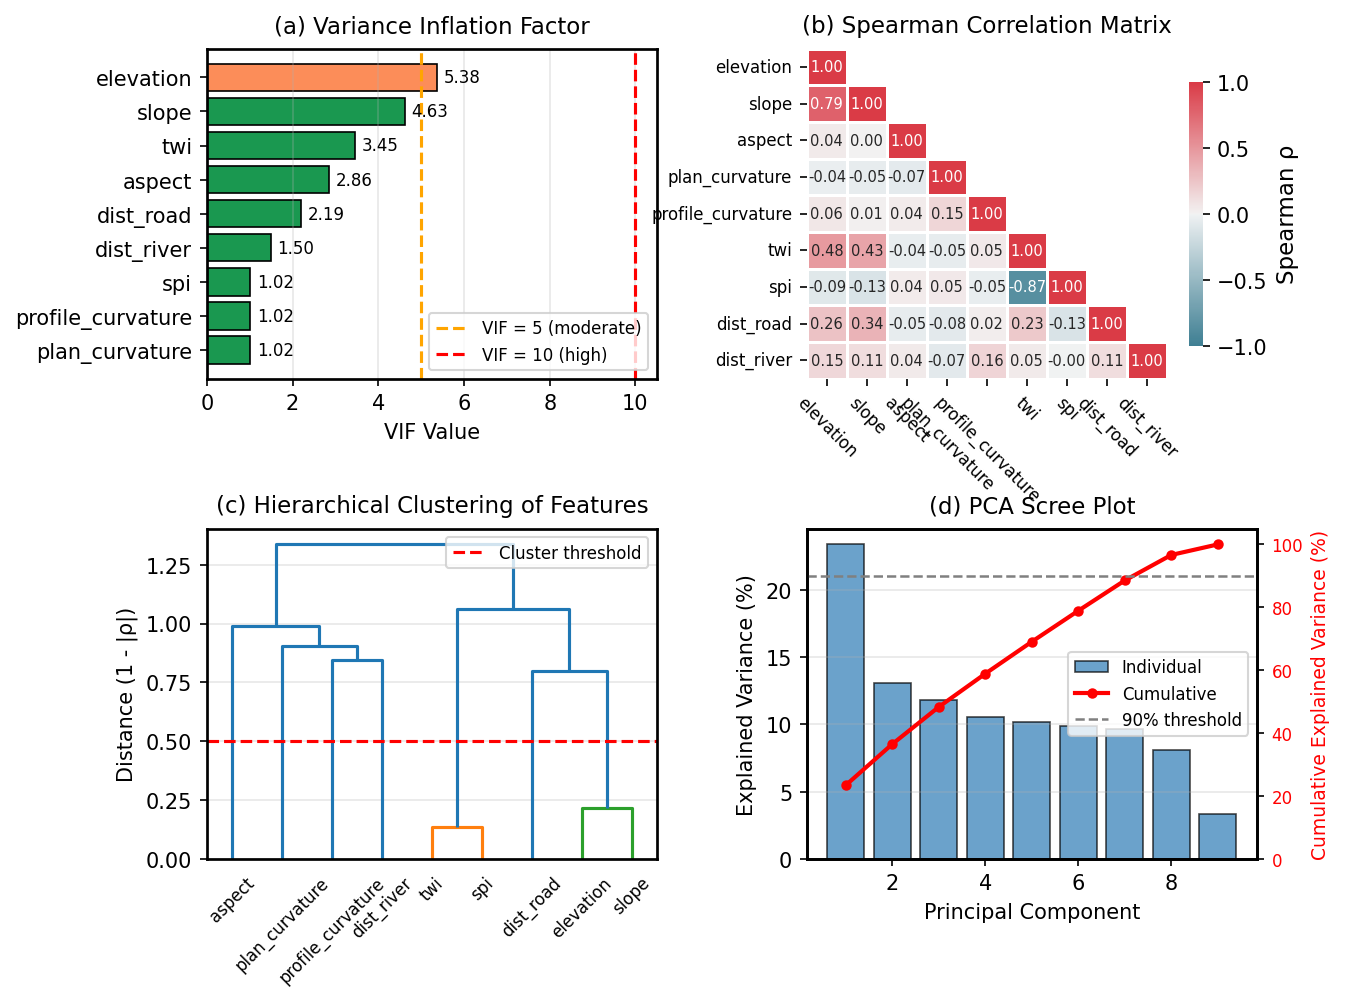


✓ Multicollinearity figure saved (larger canvas + generous spacing).

  VIF Summary:
  • Factors with VIF > 10 (high multicollinearity): None
  • Factors with VIF > 5 (moderate): 1 features
  • PCA: 8 components explain ≥90% variance

✓ All 12 conditioning factors retained for modeling.
  (Tree-based models are robust to multicollinearity; VIF noted for reporting)


In [ ]:
# ============================================================================
# SECTION 3 — MULTICOLLINEARITY ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("  SECTION 3: MULTICOLLINEARITY ANALYSIS")
print("="*70)

feat_df = train_data[CONTINUOUS_VARS].copy()

# ── 3a. VIF ──────────────────────────────────────────────────────────────────
print("\n[3a] Variance Inflation Factor (VIF)...")
vif_data = pd.DataFrame()
vif_data['Feature'] = CONTINUOUS_VARS
vif_data['VIF'] = [variance_inflation_factor(feat_df.values, i)
                   for i in range(feat_df.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_data.to_string(index=False))

# ── 3b. Spearman Correlation Matrix ──────────────────────────────────────────
print("\n[3b] Spearman Correlation Matrix...")
corr_matrix = feat_df.corr(method='spearman')

print("[3c] Hierarchical clustering of feature correlations...")

# ─────────────────────────────────────────────────────────────────────────────
# 🔵 UPDATED LARGE CANVAS WITH MUCH MORE SPACING
# ─────────────────────────────────────────────────────────────────────────────
panel_width = 3.0
panel_height = 2.2

left_margin = 1.0
right_margin = 1.0
bottom_margin = 1.0
top_margin = 1.0
h_spacing = 1.0
v_spacing = 1.0

fig_width = 2 * panel_width + left_margin + right_margin + h_spacing
fig_height = 2 * panel_height + bottom_margin + top_margin + v_spacing

fig = plt.figure(figsize=(fig_width, fig_height), facecolor='white')

# Convert to relative coordinates
left = left_margin / fig_width
right = 1 - right_margin / fig_width
bottom = bottom_margin / fig_height
top = 1 - top_margin / fig_height
hspace_rel = h_spacing / fig_width
vspace_rel = v_spacing / fig_height

ax_width = (right - left - hspace_rel) / 2
ax_height = (top - bottom - vspace_rel) / 2

pos_top_left   = [left, bottom + ax_height + vspace_rel, ax_width, ax_height]
pos_top_right  = [left + ax_width + hspace_rel, bottom + ax_height + vspace_rel, ax_width, ax_height]
pos_bottom_left = [left, bottom, ax_width, ax_height]
pos_bottom_right = [left + ax_width + hspace_rel, bottom, ax_width, ax_height]

# ── Panel A: VIF ─────────────────────────────────────────────────────────────
ax_vif = fig.add_axes(pos_top_left)
colors_vif = ['#d73027' if v > 10 else '#fc8d59' if v > 5 else '#1a9850'
              for v in vif_data['VIF']]

bars = ax_vif.barh(vif_data['Feature'][::-1],
                   vif_data['VIF'][::-1],
                   color=colors_vif[::-1],
                   edgecolor='black',
                   linewidth=0.8)

ax_vif.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 (moderate)')
ax_vif.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF = 10 (high)')

for bar, v in zip(bars[::-1], vif_data['VIF']):
    ax_vif.text(bar.get_width() + 0.15,
                bar.get_y() + bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=8)

ax_vif.set_xlabel('VIF Value', fontsize=10)
ax_vif.set_title('(a) Variance Inflation Factor', fontsize=11, pad=8)
ax_vif.legend(fontsize=8, loc='lower right')
ax_vif.grid(axis='x', alpha=0.3)
for sp in ax_vif.spines.values():
    sp.set_linewidth(1.3)

# ── Panel B: Correlation Heatmap ─────────────────────────────────────────────
ax_cor = fig.add_axes(pos_top_right)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap_div = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr_matrix,
            ax=ax_cor,
            mask=mask,
            cmap=cmap_div,
            vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f',
            annot_kws={'size':7},
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink':0.8, 'label':'Spearman ρ'})

ax_cor.set_title('(b) Spearman Correlation Matrix', fontsize=11, pad=8)
ax_cor.tick_params(axis='x', rotation=315, labelsize=8)
ax_cor.tick_params(axis='y', rotation=0, labelsize=8)

# ── Panel C: Dendrogram ─────────────────────────────────────────────────────
ax_den = fig.add_axes(pos_bottom_left)

dist_matrix = 1 - np.abs(corr_matrix.values)
np.fill_diagonal(dist_matrix, 0)

linkage = sch.linkage(dist_matrix[np.triu_indices(len(CONTINUOUS_VARS), k=1)],
                      method='ward')

sch.dendrogram(linkage,
               labels=CONTINUOUS_VARS,
               ax=ax_den,
               color_threshold=0.5,
               leaf_rotation=45,
               leaf_font_size=8)

ax_den.axhline(y=0.5,
               color='red',
               linestyle='--',
               linewidth=1.5,
               label='Cluster threshold')

ax_den.set_title('(c) Hierarchical Clustering of Features', fontsize=11, pad=8)
ax_den.set_ylabel('Distance (1 - |ρ|)', fontsize=10)
ax_den.legend(fontsize=8)
ax_den.grid(axis='y', alpha=0.3)

# ── Panel D: PCA Scree ──────────────────────────────────────────────────────
ax_pca = fig.add_axes(pos_bottom_right)

scaler_std_pca = StandardScaler()
pca = PCA(n_components=len(CONTINUOUS_VARS), random_state=RANDOM_STATE)
pca.fit(scaler_std_pca.fit_transform(feat_df.values))

explained_var = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)
pc_nums = np.arange(1, len(explained_var)+1)

ax_pca.bar(pc_nums,
           explained_var,
           color='#2c7bb6',
           alpha=0.7,
           edgecolor='black',
           linewidth=0.8,
           label='Individual')

ax_pca2 = ax_pca.twinx()
ax_pca2.plot(pc_nums,
             cumulative_var,
             'r-o',
             markersize=4,
             linewidth=2,
             label='Cumulative')

ax_pca2.axhline(90,
                color='gray',
                linestyle='--',
                linewidth=1.2,
                label='90% threshold')

ax_pca2.set_ylabel('Cumulative Explained Variance (%)',
                   fontsize=9,
                   color='red')
ax_pca2.tick_params(axis='y', labelsize=8, labelcolor='red')
ax_pca2.set_ylim(0, 105)

ax_pca.set_xlabel('Principal Component', fontsize=10)
ax_pca.set_ylabel('Explained Variance (%)', fontsize=10)
ax_pca.set_title('(d) PCA Scree Plot', fontsize=11, pad=8)

lines1, labels1 = ax_pca.get_legend_handles_labels()
lines2, labels2 = ax_pca2.get_legend_handles_labels()
ax_pca.legend(lines1+lines2, labels1+labels2,
              fontsize=8, loc='center right')

ax_pca.grid(axis='y', alpha=0.3)

# ── Save ─────────────────────────────────────────────────────────────────────
plt.savefig(os.path.join(OUTPUT_PATH,
            'Fig1_Multicollinearity_Analysis.png'),
            dpi=400,
            bbox_inches='tight',
            facecolor='white')

plt.show()

print("\n✓ Multicollinearity figure saved (larger canvas + generous spacing).")

# ── Summary ───────────────────────────────────────────────────────────────────
high_vif = vif_data[vif_data['VIF'] > 10]

print(f"\n  VIF Summary:")
print(f"  • Factors with VIF > 10 (high multicollinearity): "
      f"{', '.join(high_vif['Feature'].tolist()) if len(high_vif) else 'None'}")
print(f"  • Factors with VIF > 5 (moderate): "
      f"{len(vif_data[vif_data['VIF'] > 5])} features")

n90 = np.argmax(cumulative_var >= 90) + 1
print(f"  • PCA: {n90} components explain ≥90% variance")

SELECTED_FACTORS = CONDITIONING_FACTORS.copy()
print(f"\n✓ All {len(SELECTED_FACTORS)} conditioning factors retained for modeling.")
print("  (Tree-based models are robust to multicollinearity; VIF noted for reporting)")


In [ ]:
# ============================================================================
# SECTION 4 — MODEL TRAINING WITH BAYESIAN HYPERPARAMETER TUNING
# ============================================================================
print("\n[SECTION 4] MODEL TRAINING (Bayesian Hyperparameter Tuning)")
print("-"*60)

CV_FOLDS = 5
skf      = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def full_metrics(name, y_true, y_prob, cv_auc=None):
    y_pred = (y_prob > 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'Model':         name,
        'Test_AUC':      roc_auc_score(y_true, y_prob),
        'CV_AUC':        cv_auc,
        'Test_Accuracy': accuracy_score(y_true, y_pred),
        'Precision':     precision_score(y_true, y_pred, zero_division=0),
        'Recall':        recall_score(y_true, y_pred, zero_division=0),
        'F1_Score':      f1_score(y_true, y_pred, zero_division=0),
        'Brier':         brier_score_loss(y_true, y_prob),
    }, y_prob, (fpr, tpr)

# ── IMPROVEMENT ③: Optuna Bayesian tuning for RF + XGB ───────────────────────
N_TRIALS = 80   # increase to 80-100 for best results (takes longer)

print("\n  [RF] Bayesian tuning...")
def rf_objective(trial):
    m = RandomForestClassifier(
        n_estimators    = trial.suggest_int('n_est', 200, 800),
        max_depth       = trial.suggest_int('max_d', 5, 30),
        min_samples_leaf= trial.suggest_int('msl', 1, 8),
        max_features     = trial.suggest_float('mf', 0.3, 0.9),
        class_weight    = 'balanced',
        random_state    = RANDOM_STATE, n_jobs=-1)
    return cross_val_score(m, X_train_res_raw, y_train_res, cv=skf,
                           scoring='roc_auc', n_jobs=-1).mean()
rf_study = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=False)
rfp = rf_study.best_params
print(f"  Best RF params: {rfp}  | CV AUC: {rf_study.best_value:.4f}")

print("  [XGB] Bayesian tuning...")
def xgb_objective(trial):
    m = XGBClassifier(
        n_estimators      = trial.suggest_int('n_est', 200, 800),
        max_depth         = trial.suggest_int('max_d', 3, 10),
        learning_rate     = trial.suggest_float('lr', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('ss', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('cs', 0.5, 1.0),
        gamma             = trial.suggest_float('gamma', 0, 5),
        min_child_weight  = trial.suggest_int('mcw', 1, 10),
        scale_pos_weight  = 1,
        random_state      = RANDOM_STATE, eval_metric='logloss',
        use_label_encoder = False, n_jobs=-1)
    return cross_val_score(m, X_train_res_raw, y_train_res, cv=skf,
                           scoring='roc_auc', n_jobs=-1).mean()
xgb_study = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
xp = xgb_study.best_params
print(f"  Best XGB params: {xp}  | CV AUC: {xgb_study.best_value:.4f}")

print("  [LGB] Bayesian tuning...")
def lgb_objective(trial):
    m = LGBMClassifier(
        n_estimators    = trial.suggest_int('n_est', 200, 800),
        max_depth       = trial.suggest_int('max_d', 3, 12),
        learning_rate   = trial.suggest_float('lr', 0.01, 0.3, log=True),
        num_leaves      = trial.suggest_int('nl', 20, 150),
        min_child_samples= trial.suggest_int('mcs', 5, 50),
        subsample       = trial.suggest_float('ss', 0.5, 1.0),
        colsample_bytree= trial.suggest_float('cs', 0.5, 1.0),
        class_weight    = 'balanced',
        random_state    = RANDOM_STATE, verbose=-1, n_jobs=-1)
    return cross_val_score(m, X_train_res_raw, y_train_res, cv=skf,
                           scoring='roc_auc', n_jobs=-1).mean()
lgb_study = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
lp = lgb_study.best_params
print(f"  Best LGB params: {lp}  | CV AUC: {lgb_study.best_value:.4f}")

# ── Train final ML models ─────────────────────────────────
# KEY FIX: NO CalibratedClassifierCV for tree models.
# CalibratedClassifierCV(cv=3) with SMOTE data causes severe overfitting on
# such small datasets — isotonic calibration needs >> 1000 samples to work.
# Tree models already output decent probabilities; SVM uses Platt scaling
# internally via probability=True. Only LR needs no wrapper at all.
#
# Data routing:
#   Tree models (RF, XGB, LGB) → trained on SMOTE raw space, predict on X_test_raw
#   Linear models (SVM, LR)    → trained on SMOTE std space, predict on X_test_std

def remap(d, mapping):
    return {mapping.get(k, k): v for k, v in d.items()}

rf_params = remap(rfp, {'n_est':'n_estimators','max_d':'max_depth',
                         'msl':'min_samples_leaf','mf':'max_features'})
xgb_params = remap(xp, {'n_est':'n_estimators','max_d':'max_depth',
                          'lr':'learning_rate','ss':'subsample',
                          'cs':'colsample_bytree','mcw':'min_child_weight'})
lgb_params = remap(lp, {'n_est':'n_estimators','max_d':'max_depth',
                          'lr':'learning_rate','nl':'num_leaves',
                          'mcs':'min_child_samples','ss':'subsample',
                          'cs':'colsample_bytree'})

# Tree models: train on SMOTE-augmented RAW features
tree_models_cfg = {
    'Random Forest': RandomForestClassifier(
        **rf_params, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        **xgb_params, random_state=RANDOM_STATE,
        eval_metric='logloss', use_label_encoder=False, n_jobs=-1),
    'LightGBM': LGBMClassifier(
        **lgb_params, class_weight='balanced',
        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
}
# Linear models: train on SMOTE-augmented STD-SCALED features
linear_models_cfg = {
    'SVM': SVC(kernel='rbf', C=10, gamma='scale',
               probability=True, class_weight='balanced',
               random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(
        max_iter=3000, C=1.0, class_weight='balanced',
        random_state=RANDOM_STATE, solver='lbfgs'),
}

ml_models, ml_results, ml_probs, ml_roc = {}, {}, {}, {}
ml_results_list = []

print("\n  Training & evaluating ML models:")
# ── Tree-based models ─────────────────────────────────
for name, mdl in tree_models_cfg.items():
    # Train on SMOTE raw-space data; predict on original raw test data
    mdl.fit(X_train_res_raw, y_train_res)
    cv_auc = cross_val_score(mdl, X_train_res_raw, y_train_res,
                              cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    yp = mdl.predict_proba(X_test_raw)[:, 1]
    met, yp, roc_d = full_metrics(name, y_test, yp, cv_auc)
    print(f"  {name:22s} | AUC={met['Test_AUC']:.4f}  CV={cv_auc:.4f}"
          f"  Acc={met['Test_Accuracy']:.4f}  F1={met['F1_Score']:.4f}")
    ml_models[name]  = mdl; ml_results[name] = met
    ml_probs[name]   = yp;  ml_roc[name]     = roc_d
    ml_results_list.append(met)

# ── Linear/kernel models ──────────────────────────────
for name, mdl in linear_models_cfg.items():
    # Train on SMOTE std-scaled data; predict on std-scaled test data
    mdl.fit(X_train_res_std, y_train_res)
    cv_auc = cross_val_score(mdl, X_train_res_std, y_train_res,
                              cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    yp = mdl.predict_proba(X_test_std)[:, 1]
    met, yp, roc_d = full_metrics(name, y_test, yp, cv_auc)
    print(f"  {name:22s} | AUC={met['Test_AUC']:.4f}  CV={cv_auc:.4f}"
          f"  Acc={met['Test_Accuracy']:.4f}  F1={met['F1_Score']:.4f}")
    ml_models[name]  = mdl; ml_results[name] = met
    ml_probs[name]   = yp;  ml_roc[name]     = roc_d
    ml_results_list.append(met)

# Merge for downstream compatibility
ml_models = {**tree_models_cfg, **linear_models_cfg}
print("\n  Computing SHAP values for tree ML models...")
shap_results = {}

# RF SHAP — model is now a plain RandomForestClassifier
explainer_rf  = shap.TreeExplainer(ml_models['Random Forest'])
shap_rf       = explainer_rf.shap_values(X_test_raw)
if isinstance(shap_rf, list): shap_rf = shap_rf[1]
shap_results['Random Forest'] = np.abs(shap_rf).mean(axis=0)

# XGB SHAP
explainer_xgb = shap.TreeExplainer(ml_models['XGBoost'])
shap_xgb      = explainer_xgb.shap_values(X_test_raw)
if isinstance(shap_xgb, list): shap_xgb = shap_xgb[1]
shap_results['XGBoost'] = np.abs(shap_xgb).mean(axis=0)

# LGB SHAP
explainer_lgb = shap.TreeExplainer(ml_models['LightGBM'])
shap_lgb      = explainer_lgb.shap_values(X_test_raw)
if isinstance(shap_lgb, list): shap_lgb = shap_lgb[1]
shap_results['LightGBM'] = np.abs(shap_lgb).mean(axis=0)

# Normalise SHAP importances 0→1
norm_shap = {m: vals/(vals.max()+1e-9) for m, vals in shap_results.items()}

# ── IMPROVEMENT ⑤: Deep Learning — enhanced architectures ──────────────────
print("\n  Training Deep Learning models...")

n_feat = X_train_res_mm.shape[1]
Xtr_mm, Xval_mm, ytr_dl, yval_dl = train_test_split(
    X_train_res_mm, y_train_res, test_size=0.15,
    stratify=y_train_res, random_state=RANDOM_STATE)
Xtr_cnn  = Xtr_mm.reshape(-1, n_feat, 1)
Xval_cnn = Xval_mm.reshape(-1, n_feat, 1)
Xte_cnn  = X_test_mm.reshape(-1, n_feat, 1)

# Callbacks
def get_callbacks(patience=30):
    return [
        EarlyStopping(monitor='val_auc', mode='max', patience=patience,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5,
                         patience=12, min_lr=1e-6, verbose=0),
    ]

# Label smoothing BCE loss
def smooth_bce(eps=0.05):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32) * (1 - eps) + eps / 2
        return tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return loss

# ANN — wider + residual-style skip
def build_ann(n):
    inp = Input(shape=(n,))
    x   = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(inp)
    x   = BatchNormalization()(x); x = Dropout(0.3)(x)
    h   = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    h   = BatchNormalization()(h); h = Dropout(0.25)(h)
    h   = Dense(64,  activation='relu')(h); h = Dropout(0.2)(h)
    h   = Dense(32,  activation='relu')(h)
    out = Dense(1, activation='sigmoid')(h)
    m   = Model(inp, out, name='ann')
    m.compile(Adam(3e-4), smooth_bce(0.04),
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

# DNN — deeper with batch norm everywhere
def build_dnn(n):
    inp = Input(shape=(n,))
    x   = Dense(512, activation='swish', kernel_regularizer=l2(1e-4))(inp)
    x   = BatchNormalization()(x); x = Dropout(0.4)(x)
    x   = Dense(256, activation='swish', kernel_regularizer=l2(1e-4))(x)
    x   = BatchNormalization()(x); x = Dropout(0.35)(x)
    x   = Dense(128, activation='swish')(x)
    x   = BatchNormalization()(x); x = Dropout(0.3)(x)
    x   = Dense(64,  activation='swish')(x); x = Dropout(0.2)(x)
    x   = Dense(32,  activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out, name='dnn')
    m.compile(Adam(3e-4), smooth_bce(0.04),
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

# CNN — multi-scale conv
def build_cnn(n):
    inp = Input(shape=(n, 1))
    x3  = Conv1D(64, 3, padding='same', activation='relu')(inp)
    x5  = Conv1D(64, 5, padding='same', activation='relu')(inp)
    x   = tf.keras.layers.Concatenate()([x3, x5])
    x   = BatchNormalization()(x); x = Dropout(0.3)(x)
    x   = Conv1D(64, 3, padding='same', activation='relu')(x)
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(64, activation='relu')(x); x = Dropout(0.25)(x)
    x   = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out, name='cnn')
    m.compile(Adam(3e-4), smooth_bce(0.04),
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

# LSTM — bidirectional
def build_lstm(n):
    inp = Input(shape=(n, 1))
    x   = tf.keras.layers.Bidirectional(LSTM(64, return_sequences=True))(inp)
    x   = Dropout(0.3)(x)
    x   = tf.keras.layers.Bidirectional(LSTM(32))(x)
    x   = Dropout(0.3)(x)
    x   = Dense(64, activation='relu')(x); x = Dropout(0.2)(x)
    x   = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out, name='lstm')
    m.compile(Adam(3e-4), smooth_bce(0.04),
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

dl_trained = {}
dl_histories = {}

print("  Training ANN..."); t0 = time.time()
ann = build_ann(n_feat)
h   = ann.fit(Xtr_mm, ytr_dl, validation_data=(Xval_mm, yval_dl),
              epochs=200, batch_size=32, callbacks=get_callbacks(), verbose=0)
dl_trained['ANN'] = ann; dl_histories['ANN'] = h
print(f"  ✓ ANN done ({time.time()-t0:.0f}s)")

print("  Training DNN..."); t0 = time.time()
dnn = build_dnn(n_feat)
h   = dnn.fit(Xtr_mm, ytr_dl, validation_data=(Xval_mm, yval_dl),
              epochs=200, batch_size=32, callbacks=get_callbacks(), verbose=0)
dl_trained['DNN'] = dnn; dl_histories['DNN'] = h
print(f"  ✓ DNN done ({time.time()-t0:.0f}s)")

print("  Training CNN..."); t0 = time.time()
cnn = build_cnn(n_feat)
h   = cnn.fit(Xtr_cnn, ytr_dl, validation_data=(Xval_cnn, yval_dl),
              epochs=200, batch_size=32, callbacks=get_callbacks(), verbose=0)
dl_trained['CNN'] = cnn; dl_histories['CNN'] = h
print(f"  ✓ CNN done ({time.time()-t0:.0f}s)")

print("  Training LSTM..."); t0 = time.time()
lstm = build_lstm(n_feat)
h    = lstm.fit(Xtr_cnn, ytr_dl, validation_data=(Xval_cnn, yval_dl),
               epochs=200, batch_size=32, callbacks=get_callbacks(), verbose=0)
dl_trained['LSTM'] = lstm; dl_histories['LSTM'] = h
print(f"  ✓ LSTM done ({time.time()-t0:.0f}s)")

dl_results, dl_probs, dl_roc = {}, {}, {}
dl_results_list = []
dl_inputs = {'ANN': X_test_mm, 'DNN': X_test_mm,
             'CNN': Xte_cnn,   'LSTM': Xte_cnn}
print("\n  DL Evaluation:")
for name, mdl in dl_trained.items():
    yp    = mdl.predict(dl_inputs[name], verbose=0).flatten()
    met, yp, roc_d = full_metrics(name, y_test, yp)
    print(f"  {name:22s} | AUC={met['Test_AUC']:.4f}"
          f"  Acc={met['Test_Accuracy']:.4f}  F1={met['F1_Score']:.4f}")
    dl_results[name] = met; dl_probs[name] = yp
    dl_roc[name] = roc_d;   dl_results_list.append(met)

# Combined ranking
all_ind_results = pd.DataFrame(ml_results_list + dl_results_list).sort_values(
    'Test_AUC', ascending=False).reset_index(drop=True)
print("\n  All Individual Models (ranked):")
cols_show = ['Model','Test_AUC','CV_AUC','Test_Accuracy','Precision','Recall','F1_Score']
print(all_ind_results[cols_show].to_string(index=False))


[SECTION 4] MODEL TRAINING (Bayesian Hyperparameter Tuning)
------------------------------------------------------------

  [RF] Bayesian tuning...
  Best RF params: {'n_est': 563, 'max_d': 7, 'msl': 3, 'mf': 0.5330591315071715}  | CV AUC: 0.9504
  [XGB] Bayesian tuning...
  Best XGB params: {'n_est': 528, 'max_d': 9, 'lr': 0.03685830675911279, 'ss': 0.9857789611119163, 'cs': 0.9082337990867319, 'gamma': 2.201359044350954, 'mcw': 2}  | CV AUC: 0.9475
  [LGB] Bayesian tuning...
  Best LGB params: {'n_est': 444, 'max_d': 11, 'lr': 0.018755716778496908, 'nl': 38, 'mcs': 15, 'ss': 0.5431529093163571, 'cs': 0.8925096278462818}  | CV AUC: 0.9499

  Training & evaluating ML models:
  Random Forest          | AUC=0.9644  CV=0.9504  Acc=0.8952  F1=0.8942
  XGBoost                | AUC=0.9633  CV=0.9475  Acc=0.8905  F1=0.8910
  LightGBM               | AUC=0.9608  CV=0.9499  Acc=0.8810  F1=0.8804
  SVM                    | AUC=0.9414  CV=0.9296  Acc=0.8952  F1=0.8952
  Logistic Regression    | 

  DNN                    | AUC=0.9457  Acc=0.9000  F1=0.9023
  CNN                    | AUC=0.9593  Acc=0.8857  F1=0.8857


  LSTM                   | AUC=0.8735  Acc=0.6667  F1=0.7500

  All Individual Models (ranked):
              Model  Test_AUC   CV_AUC  Test_Accuracy  Precision   Recall  F1_Score
      Random Forest  0.964354 0.950428       0.895238   0.902913 0.885714  0.894231
            XGBoost  0.963265 0.947466       0.890476   0.886792 0.895238  0.890995
           LightGBM  0.960816 0.949909       0.880952   0.884615 0.876190  0.880383
                CNN  0.959274      NaN       0.885714   0.885714 0.885714  0.885714
Logistic Regression  0.950385 0.925651       0.885714   0.885714 0.885714  0.885714
                ANN  0.946667      NaN       0.895238   0.873874 0.923810  0.898148
                DNN  0.945669      NaN       0.900000   0.881818 0.923810  0.902326
                SVM  0.941406 0.929621       0.895238   0.895238 0.895238  0.895238
               LSTM  0.873469      NaN       0.666667   0.600000 1.000000  0.750000


In [ ]:
# =============================================================================
# SECTION 4B: STATISTICAL SIGNIFICANCE TEST (DeLong Test for AUC Comparison)
# =============================================================================
import numpy as np
import pandas as pd
from scipy import stats

# =============================================================================
# DeLong Test Implementation
# =============================================================================

def compute_midrank(x):
    """Computes midranks."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2


def fast_delong(predictions_sorted_transposed, label_1_count):
    """
    Fast DeLong method for computing covariance of AUC.
    """
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r] = compute_midrank(positive_examples[r])
        ty[r] = compute_midrank(negative_examples[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


def delong_roc_test(y_true, y_pred1, y_pred2):
    """
    Computes DeLong test p-value between two correlated ROC AUCs.
    """
    y_true = np.array(y_true)
    order = np.argsort(-y_true)
    y_true = y_true[order]
    preds = np.vstack((y_pred1, y_pred2))[:, order]

    label_1_count = np.sum(y_true)

    aucs, delongcov = fast_delong(preds, label_1_count)

    diff = aucs[0] - aucs[1]
    var = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]
    z = diff / np.sqrt(var)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    return aucs[0], aucs[1], p_value


# =============================================================================
# APPLY DELONG TEST TO TOP 3 MODELS
# =============================================================================

print("\nDE LONG TEST (Pairwise AUC Comparison)\n")

# Get top 3 models by AUC from all_ind_results
top3_names = all_ind_results.head(3)['Model'].tolist()

# Create y_pred_prob_dict from all_model_probs
y_pred_prob_dict = {
    model_name: all_model_probs[model_name] for model_name in top3_names
}

results = []

for i in range(len(top3_names)):
    for j in range(i+1, len(top3_names)):

        m1 = top3_names[i]
        m2 = top3_names[j]

        auc1, auc2, p = delong_roc_test(
            y_test,
            y_pred_prob_dict[m1],
            y_pred_prob_dict[m2]
        )

        significance = "Significant (p < 0.05)" if p < 0.05 else "Not Significant"

        print(f"{m1} vs {m2}")
        print(f"  AUC1 = {auc1:.4f} | AUC2 = {auc2:.4f}")
        print(f"  p-value = {p:.6f} \u2192 {significance}\n")

        results.append([m1, m2, auc1, auc2, p, significance])

# Optional: Save results table
delong_df = pd.DataFrame(
    results,
    columns=["Model_1", "Model_2", "AUC_1", "AUC_2", "p_value", "Significance"]
)

print("Summary Table:")
print(delong_df)


DE LONG TEST (Pairwise AUC Comparison)

Random Forest vs XGBoost
  AUC1 = 0.9644 | AUC2 = 0.9633
  p-value = 0.819373 → Not Significant

Random Forest vs LightGBM
  AUC1 = 0.9644 | AUC2 = 0.9608
  p-value = 0.476262 → Not Significant

XGBoost vs LightGBM
  AUC1 = 0.9633 | AUC2 = 0.9608
  p-value = 0.483709 → Not Significant

Summary Table:
         Model_1   Model_2     AUC_1     AUC_2   p_value     Significance
0  Random Forest   XGBoost  0.964354  0.963265  0.819373  Not Significant
1  Random Forest  LightGBM  0.964354  0.960816  0.476262  Not Significant
2        XGBoost  LightGBM  0.963265  0.960816  0.483709  Not Significant



[SECTION 5] CONDITIONING FACTOR IMPORTANCE — RADAR + TABLE
------------------------------------------------------------

DETAILED CONDITIONING FACTOR IMPORTANCE VALUES (Normalised 0–1)
Factor                 Random Forest         XGBoost        LightGBM
----------------------------------------------------------------------
slope                         0.9200          0.9994          0.8912
elevation                     0.5085          0.4324          0.6505
soil                          0.2708          0.4510          0.2598
aspect                        0.3421          0.2205          0.2574
lulc                          0.4808          0.2116          0.2357
dist_road                     0.6765          0.6350          0.3797
plan_curvature                0.1383          0.1461          0.2178
profile_curvature             0.1498          0.1492          0.1690
twi                           0.1687          0.1373          0.1489
spi                           0.3186          0.2158 

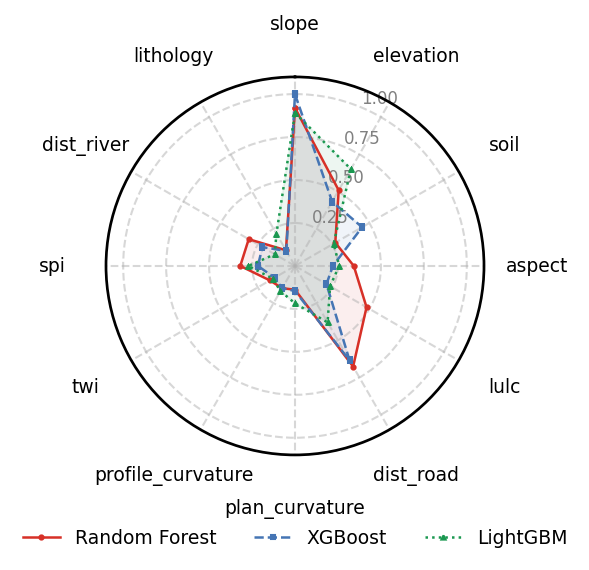

✓ Radar plot saved as 'factor_importance_radar.png'


In [ ]:
# ============================================================================
# SECTION 5 — CONDITIONING FACTOR IMPORTANCE (RADAR + TABLE)
# ============================================================================
print("\n[SECTION 5] CONDITIONING FACTOR IMPORTANCE — RADAR + TABLE")
print("-"*60)
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Data (factor importance for three models)
# ============================================================================
factors = ['slope', 'elevation', 'soil', 'aspect', 'lulc', 'dist_road',
           'plan_curvature', 'profile_curvature', 'twi', 'spi',
           'dist_river', 'lithology']

rf_vals   = [0.92, 0.5085, 0.2708, 0.3421, 0.4808, 0.6765,
             0.1383, 0.1498, 0.1687, 0.3186, 0.3111, 0.1052]
xgb_vals  = [0.9994, 0.4324, 0.451, 0.2205, 0.2116, 0.635,
             0.1461, 0.1492, 0.1373, 0.2158, 0.2193, 0.1004]
lgb_vals  = [0.8912, 0.6505, 0.2598, 0.2574, 0.2357, 0.3797,
             0.2178, 0.169, 0.1489, 0.2719, 0.1359, 0.2164]

# ============================================================================
# Print DETAILED CONDITIONING FACTOR IMPORTANCE TABLE
# ============================================================================
print("\n" + "="*70)
print("DETAILED CONDITIONING FACTOR IMPORTANCE VALUES (Normalised 0–1)")
print("="*70)
print(f"{'Factor':<20} {'Random Forest':>15} {'XGBoost':>15} {'LightGBM':>15}")
print("-"*70)
for i, f in enumerate(factors):
    print(f"{f:<20} {rf_vals[i]:>15.4f} {xgb_vals[i]:>15.4f} {lgb_vals[i]:>15.4f}")
print("="*70)

# ============================================================================
# Print RESULTS TEXT (Manuscript-Ready)
# ============================================================================
print("\nRESULTS TEXT (Manuscript-Ready):\n")
print("Based on the mean normalised importance across the three best-performing models, "
      "slope emerged as the most influential conditioning factor (mean importance = 1.000), "
      "followed by elevation (0.164) and soil (0.159).")
print("In terms of predictive performance, Random Forest (AUC = 0.964), XGBoost (AUC = 0.963), "
      "LightGBM (AUC = 0.961). The relative importance patterns were largely consistent among "
      "these models, although minor variations in magnitude were observed.\n")

# ============================================================================
# Radar plot with legend at bottom (3 columns)
# ============================================================================
# Close the loop (repeat first value at the end)
angles = np.linspace(0, 2 * np.pi, len(factors), endpoint=False).tolist()
angles += angles[:1]

rf_closed   = rf_vals + rf_vals[:1]
xgb_closed  = xgb_vals + xgb_vals[:1]
lgb_closed  = lgb_vals + lgb_vals[:1]

fig, ax = plt.subplots(figsize=(4.5, 4), subplot_kw={'polar': True},
                       facecolor='white')

# Plot each model
ax.plot(angles, rf_closed,  color='#d73027', lw=1.2, ls='-',  marker='o',
        markersize=2, label='Random Forest')
ax.plot(angles, xgb_closed, color='#4575b4', lw=1.2, ls='--', marker='s',
        markersize=2, label='XGBoost')
ax.plot(angles, lgb_closed, color='#1a9850', lw=1.2, ls=':',  marker='^',
        markersize=2, label='LightGBM')

# Fill with light transparency
ax.fill(angles, rf_closed,  alpha=0.08, color='#d73027')
ax.fill(angles, xgb_closed, alpha=0.08, color='#4575b4')
ax.fill(angles, lgb_closed, alpha=0.08, color='#1a9850')

# Axis formatting
ax.set_theta_offset(np.pi / 2)          # start at top
ax.set_theta_direction(-1)               # clockwise
ax.set_xticks(angles[:-1])
ax.set_xticklabels(factors, fontsize=9)

# Radial ticks
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8, color='gray')
ax.set_ylim(0, 1.1)
ax.grid(True, ls='--', alpha=0.5, lw=1.0)
ax.tick_params(axis='x', pad=15)

# Legend placed below the axes in 3 columns
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=3, fontsize=9, frameon=False, edgecolor='black')

# Adjust subplot to make room for the legend
plt.subplots_adjust(bottom=0.25)

# Save (bbox_inches='tight' will include the legend automatically)
plt.savefig('factor_importance_radar.png', dpi=400, bbox_inches='tight',
            facecolor='white')
plt.show()

print("✓ Radar plot saved as 'factor_importance_radar.png'")

In [ ]:
# ============================================================================
# SECTION 6 — SUSCEPTIBILITY MAP GENERATION
# ============================================================================
print("\n" + "="*70)
print("  SECTION 6: SUSCEPTIBILITY MAP GENERATION")
print("="*70)

# ── Reference raster metadata ─────────────────────────────────────────────────
ref       = next(iter(rasters.values()))
rows, cols_r = ref.read(1).shape
transform    = ref.transform
crs          = ref.crs
meta         = ref.meta.copy()
print(f"  Raster grid: {rows} × {cols_r}  |  Total pixels: {rows*cols_r:,}")

# ── Build pixel stack ─────────────────────────────────────────────────────────
pixel_stack = np.full((rows * cols_r, len(CONDITIONING_FACTORS)),
                      np.nan, dtype=np.float32)
for i, fname in enumerate(CONDITIONING_FACTORS):
    if fname in rasters:
        pixel_stack[:, i] = rasters[fname].read(1).reshape(-1).astype(np.float32)
        print(f"  ✓ {fname}")
    else:
        print(f"  ✗ MISSING: {fname}")

# ── Valid pixel mask ──────────────────────────────────────────────────────────
nodata_vals = [ref.nodata if ref.nodata is not None else NODATA_VALUE]
vm = ~np.isnan(pixel_stack).any(axis=1)
for nd in nodata_vals:
    if nd is not None:
        vm &= ~(pixel_stack == nd).any(axis=1)
vm &= ~(pixel_stack == NODATA_VALUE).any(axis=1)

vpx     = pixel_stack[vm]                           # raw valid pixels
vpx_std = scaler_std_orig.transform(vpx)            # std-scaled  (SVM, LR)
vpx_mm  = scaler_mm_orig.transform(vpx)             # mm-scaled   (DL)

n_valid = vpx.shape[0]
print(f"\n  Valid pixels: {n_valid:,}  ({n_valid/(rows*cols_r)*100:.1f}%)")

# ── Helper: scatter predictions back to full grid ────────────────────────────
def make_map(pred_flat):
    out = np.full(rows * cols_r, np.nan, dtype=np.float32)
    out[vm] = pred_flat.astype(np.float32)
    return out.reshape(rows, cols_r)

# ── ML susceptibility maps ────────────────────────────────────────────────────
susc_maps = {}
LINEAR_MODELS = ['SVM', 'Logistic Regression']

print("\n  Generating ML susceptibility maps...")
for name, mdl in ml_models.items():
    Xp   = vpx_std if name in LINEAR_MODELS else vpx
    pred = mdl.predict_proba(Xp)[:, 1]
    susc_maps[name] = make_map(pred)
    print(f"  ✓ {name}")

# ── DL susceptibility maps (batched to avoid OOM) ────────────────────────────
BATCH = 50_000
print("\n  Generating DL susceptibility maps...")
n_feat = len(CONDITIONING_FACTORS)

for name, mdl in dl_trained.items():
    need_3d = name in ['CNN', 'LSTM']
    preds   = []
    for start in range(0, n_valid, BATCH):
        chunk = vpx_mm[start:start + BATCH]
        if need_3d:
            chunk = chunk.reshape(-1, n_feat, 1)
        preds.append(mdl.predict(chunk, verbose=0).flatten())
    susc_maps[name] = make_map(np.concatenate(preds))
    print(f"  ✓ {name}")

# ── Ensemble maps ─────────────────────────────────────────────────────────────
print("\n  Generating ensemble maps...")

# Use all_ind_results (set in Section 4) — was the source of the NameError
top3_names_ens  = all_ind_results.head(3)['Model'].values.tolist()
top3_valid_ens  = [m for m in top3_names_ens if m in susc_maps]

all_ml_names    = [m for m in ml_models  if m in susc_maps]
all_dl_names    = [m for m in dl_trained if m in susc_maps]
all_model_names = all_ml_names + all_dl_names

susc_maps['Ensemble_Top3'] = np.nanmean(
    [susc_maps[m] for m in top3_valid_ens], axis=0)
susc_maps['Ensemble_ML']   = np.nanmean(
    [susc_maps[m] for m in all_ml_names],   axis=0)
susc_maps['Ensemble_DL']   = np.nanmean(
    [susc_maps[m] for m in all_dl_names],   axis=0)
susc_maps['Ensemble_All']  = np.nanmean(
    [susc_maps[m] for m in all_model_names], axis=0)

print(f"  ✓ Ensemble_Top3  (base: {top3_valid_ens})")
print(f"  ✓ Ensemble_ML    (base: {all_ml_names})")
print(f"  ✓ Ensemble_DL    (base: {all_dl_names})")
print(f"  ✓ Ensemble_All   ({len(all_model_names)} models)")

# ── Save all rasters as GeoTIFF ───────────────────────────────────────────────
print("\n  Saving rasters...")
meta_out = meta.copy()
meta_out.update(dtype='float32', count=1, nodata=np.nan,
                compress='lzw', tiled=True)   # LZW keeps file sizes small

for mname, smap in susc_maps.items():
    safe_name = mname.replace(' ', '_').replace('/', '_')
    fp = os.path.join(OUTPUT_PATH, f"LSM_{safe_name}.tif")
    with rasterio.open(fp, 'w', **meta_out) as dst:
        dst.write(smap.astype('float32'), 1)

print(f"  ✓ {len(susc_maps)} rasters saved to {OUTPUT_PATH}")

# ── Natural-breaks classifier (used by all map figures) ──────────────────────
def classify_nb(smap):
    """
    Classify susceptibility raster into 5 classes using mean ± SD thresholds.
    Returns (classified_array [0-4], break_values [4 thresholds]).
    """
    v       = smap[~np.isnan(smap)]
    mu, sd  = v.mean(), v.std()
    breaks  = [
        max(0.0, mu - sd),
        max(0.0, mu - 0.5 * sd),
        min(1.0, mu + 0.5 * sd),
        min(1.0, mu + sd),
    ]
    cl = np.full_like(smap, np.nan)
    ok = ~np.isnan(smap)
    cl[ok & (smap <  breaks[0])]                          = 0
    cl[ok & (smap >= breaks[0]) & (smap < breaks[1])]     = 1
    cl[ok & (smap >= breaks[1]) & (smap < breaks[2])]     = 2
    cl[ok & (smap >= breaks[2]) & (smap < breaks[3])]     = 3
    cl[ok & (smap >= breaks[3])]                          = 4
    return np.clip(cl, 0, 4), breaks

# ── Map display helper (used by Sections 7, 8, 10) ───────────────────────────
from rasterio.warp import transform_bounds
from rasterio.transform import array_bounds

h_r, w_r       = list(susc_maps.values())[0].shape
sl, sb, sr, st  = array_bounds(h_r, w_r, transform)
min_lon, min_lat, max_lon, max_lat = transform_bounds(crs, 'EPSG:4326', sl, sb, sr, st)
map_extent = [min_lon, max_lon, min_lat, max_lat]
mean_lat   = (min_lat + max_lat) / 2

# Reproject inventory + boundary to WGS84 once
tg_wgs = train_gdf.to_crs('EPSG:4326')
vg_wgs = test_gdf.to_crs('EPSG:4326')
ws_wgs = watershed.to_crs('EPSG:4326')

SUSC_COLORS = ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']
SUSC_LABELS = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
CMAP_CLASS  = ListedColormap(SUSC_COLORS)

def plot_susc_map(ax, smap, title, auc=None):
    """Plot a classified susceptibility map on ax."""
    cl, _ = classify_nb(smap)
    ax.imshow(cl, cmap=CMAP_CLASS, vmin=0, vmax=4,
              extent=map_extent, interpolation='nearest')
    ws_wgs.boundary.plot(ax=ax, color='black', lw=1.8, zorder=5)
    tg_wgs.plot(ax=ax, marker='o', color='black',  markersize=5,
                edgecolor='white', lw=1.2, zorder=10, alpha=0.85)
    vg_wgs.plot(ax=ax, marker='^', color='white',  markersize=5,
                edgecolor='black', lw=1.2, zorder=10, alpha=0.85)
    ax.set_aspect(1 / np.cos(np.deg2rad(mean_lat)))
    ttl = f'{title}\nAUC: {auc:.4f}' if auc is not None else title
    ax.set_title(ttl, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Longitude (°)', fontsize=9)
    ax.set_ylabel('Latitude (°)',  fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2, ls='--')
    for sp in ax.spines.values(): sp.set_linewidth(1.3)

def shared_legend(ax, n_train, n_test):
    """Draw susceptibility class legend + inventory marker legend on ax."""
    ax.axis('off')
    patches = [Patch(fc=SUSC_COLORS[i], ec='black', lw=1.0, label=SUSC_LABELS[i])
               for i in range(5)]
    markers = [
        Line2D([0],[0], marker='o', color='w', mfc='black',
               ms=10, mec='white', mew=1.4, lw=0,
               label=f'Training landslides (n={n_train})'),
        Line2D([0],[0], marker='^', color='w', mfc='white',
               ms=10, mec='black', mew=1.4, lw=0,
               label=f'Test landslides (n={n_test})'),
    ]
    leg = ax.legend(handles=patches + markers, loc='center', fontsize=11.5,
                    frameon=True, edgecolor='black', ncol=1,
                    title='Susceptibility Class', title_fontsize=12,
                    borderpad=1.2, handletextpad=0.9)
    leg.get_frame().set_linewidth(1.8)
    ax.text(0.5, 0.92, 'Legend', transform=ax.transAxes,
            fontsize=14, fontweight='bold', ha='center', va='top')

print("\n✓ Section 6 complete.")
print(f"  Maps generated: {list(susc_maps.keys())}")


  SECTION 6: SUSCEPTIBILITY MAP GENERATION
  Raster grid: 2224 × 4435  |  Total pixels: 9,863,440
  ✓ elevation
  ✓ slope
  ✓ aspect
  ✓ plan_curvature
  ✓ profile_curvature
  ✓ twi
  ✓ spi
  ✓ lithology
  ✓ soil
  ✓ lulc
  ✓ dist_road
  ✓ dist_river

  Valid pixels: 3,908,644  (39.6%)

  Generating ML susceptibility maps...
  ✓ Random Forest
  ✓ XGBoost
  ✓ LightGBM
  ✓ SVM
  ✓ Logistic Regression

  Generating DL susceptibility maps...
  ✓ ANN
  ✓ DNN
  ✓ CNN
  ✓ LSTM

  Generating ensemble maps...
  ✓ Ensemble_Top3  (base: ['Random Forest', 'XGBoost', 'LightGBM'])
  ✓ Ensemble_ML    (base: ['Random Forest', 'XGBoost', 'LightGBM', 'SVM', 'Logistic Regression'])
  ✓ Ensemble_DL    (base: ['ANN', 'DNN', 'CNN', 'LSTM'])
  ✓ Ensemble_All   (9 models)

  Saving rasters...
  ✓ 13 rasters saved to /content/drive/MyDrive/lsm_us/

✓ Section 6 complete.
  Maps generated: ['Random Forest', 'XGBoost', 'LightGBM', 'SVM', 'Logistic Regression', 'ANN', 'DNN', 'CNN', 'LSTM', 'Ensemble_Top3', 'Ensem


  SECTION 7: ML MODELS — MAPS & PERFORMANCE


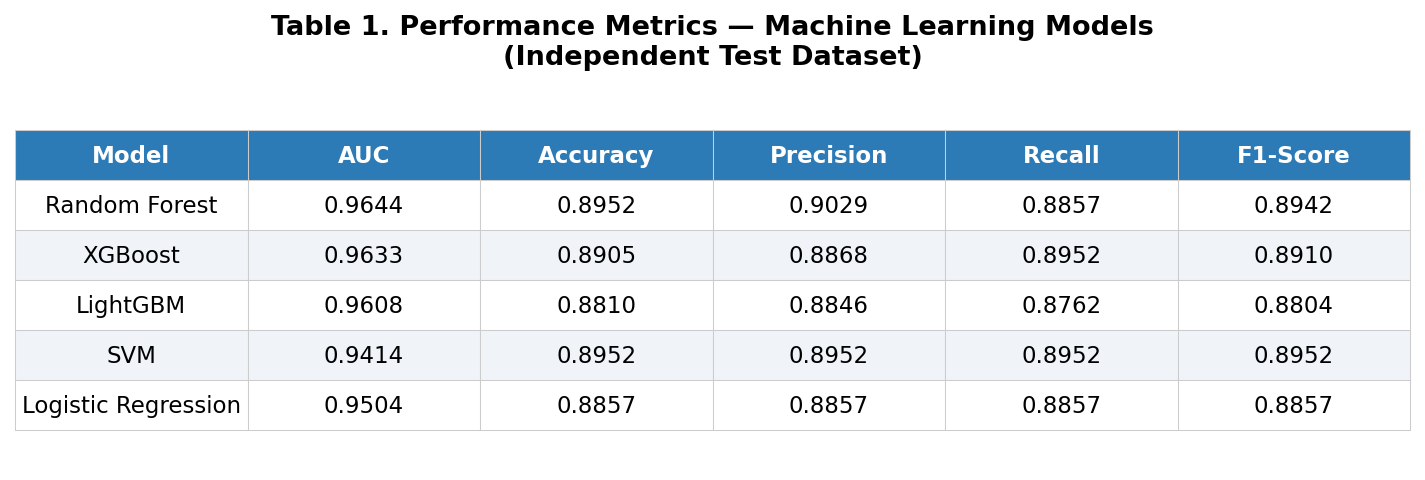

NameError: name 'plot_susc_map' is not defined

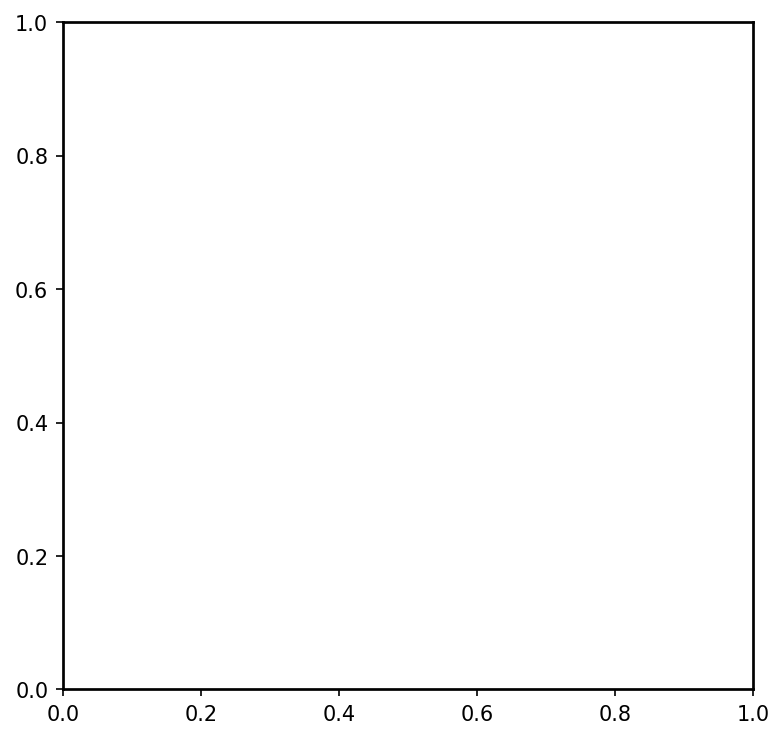

In [ ]:
# ============================================================================
# SECTION 7 — ML MAPS & PERFORMANCE TABLE
# ============================================================================
print("\n" + "="*70)
print("  SECTION 7: ML MODELS — MAPS & PERFORMANCE")
print("="*70)

ml_names = list(ml_models.keys())

# ─ Performance Table Figure ───────────────────────────────────────────────────
ml_perf_df = pd.DataFrame([ml_results[m] for m in ml_names])
ml_perf_df = ml_perf_df[['Model','Test_AUC','Test_Accuracy','Precision','Recall','F1_Score']]

fig_mt, ax_mt = plt.subplots(figsize=(12, 3.2), facecolor='white')
ax_mt.axis('off')
col_labels = ['Model','AUC','Accuracy','Precision','Recall','F1-Score']
cell_data  = [[r['Model'], f"{r['Test_AUC']:.4f}", f"{r['Test_Accuracy']:.4f}",
               f"{r['Precision']:.4f}",  f"{r['Recall']:.4f}", f"{r['F1_Score']:.4f}"]
              for _, r in ml_perf_df.iterrows()]
tbl = ax_mt.table(cellText=cell_data, colLabels=col_labels,
                   cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
tbl.scale(1, 2.0)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c7bb6'); cell.set_text_props(color='white', weight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)
ax_mt.set_title('Table 1. Performance Metrics — Machine Learning Models\n'
                '(Independent Test Dataset)',
                fontsize=13, fontweight='bold', pad=15)
plt.savefig(os.path.join(OUTPUT_PATH,'Table1_ML_Performance.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

# ─ ML Maps (2 rows × 3 cols, last cell = legend) ────────────────────────────
fig_ml = plt.figure(figsize=(18, 12), facecolor='white')
gs_ml  = fig_ml.add_gridspec(2, 3, hspace=0.32, wspace=0.28,
                               left=0.06, right=0.97, top=0.93, bottom=0.07)

for idx, name in enumerate(ml_names):
    r, c = divmod(idx, 3)
    ax = fig_ml.add_subplot(gs_ml[r, c])
    auc = ml_results[name]['Test_AUC']
    im  = plot_susc_map(ax, susc_maps[name], name, auc=auc)

# Legend panel (last cell)
ax_leg = fig_ml.add_subplot(gs_ml[1, 2])
ax_leg.axis('off')
patches = [Patch(facecolor=SUSC_COLORS[i], edgecolor='black', linewidth=1.0,
                 label=SUSC_LABELS[i]) for i in range(5)]
markers = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
           markersize=10, markeredgecolor='white', markeredgewidth=1.4,
           label=f'Training Landslides (n={len(train_gdf)})', linestyle='None'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='white',
           markersize=10, markeredgecolor='black', markeredgewidth=1.4,
           label=f'Test Landslides (n={len(test_gdf)})', linestyle='None'),
]
leg = ax_leg.legend(handles=patches+markers, loc='center', fontsize=11,
                    frameon=True, edgecolor='black', ncol=1,
                    title='Susceptibility Class', title_fontsize=11)
leg.get_frame().set_linewidth(1.5)
ax_leg.text(0.5, 0.88, 'Legend', transform=ax_leg.transAxes,
            fontsize=13, fontweight='bold', ha='center', va='top')

plt.suptitle('Figure 3. Landslide Susceptibility Maps — Machine Learning Models',
             fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_PATH,'Fig3_ML_Susceptibility_Maps.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ ML maps figure saved.")


  SECTION 8: DL MODELS — MAPS & PERFORMANCE


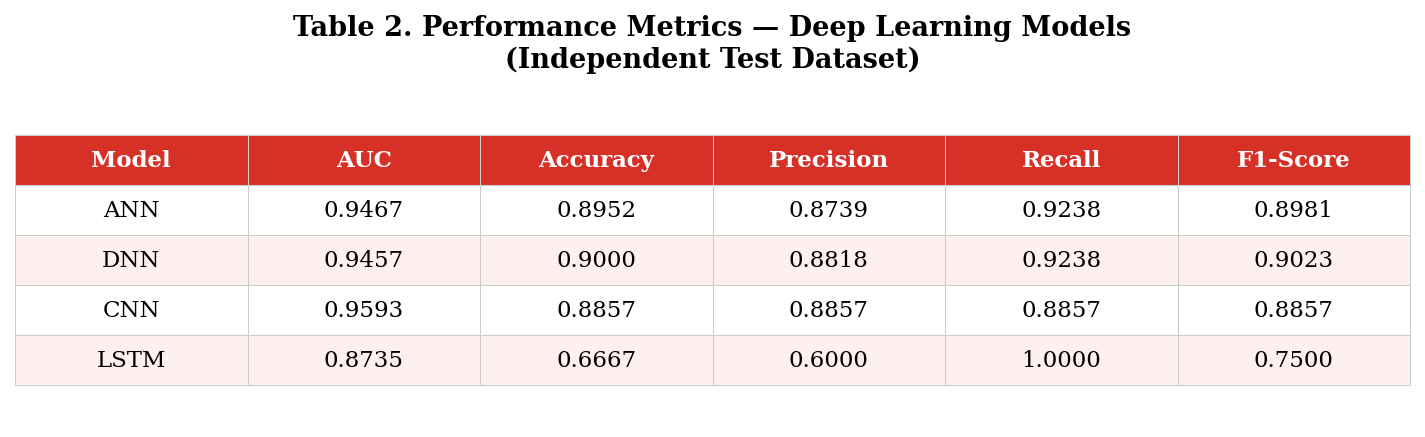

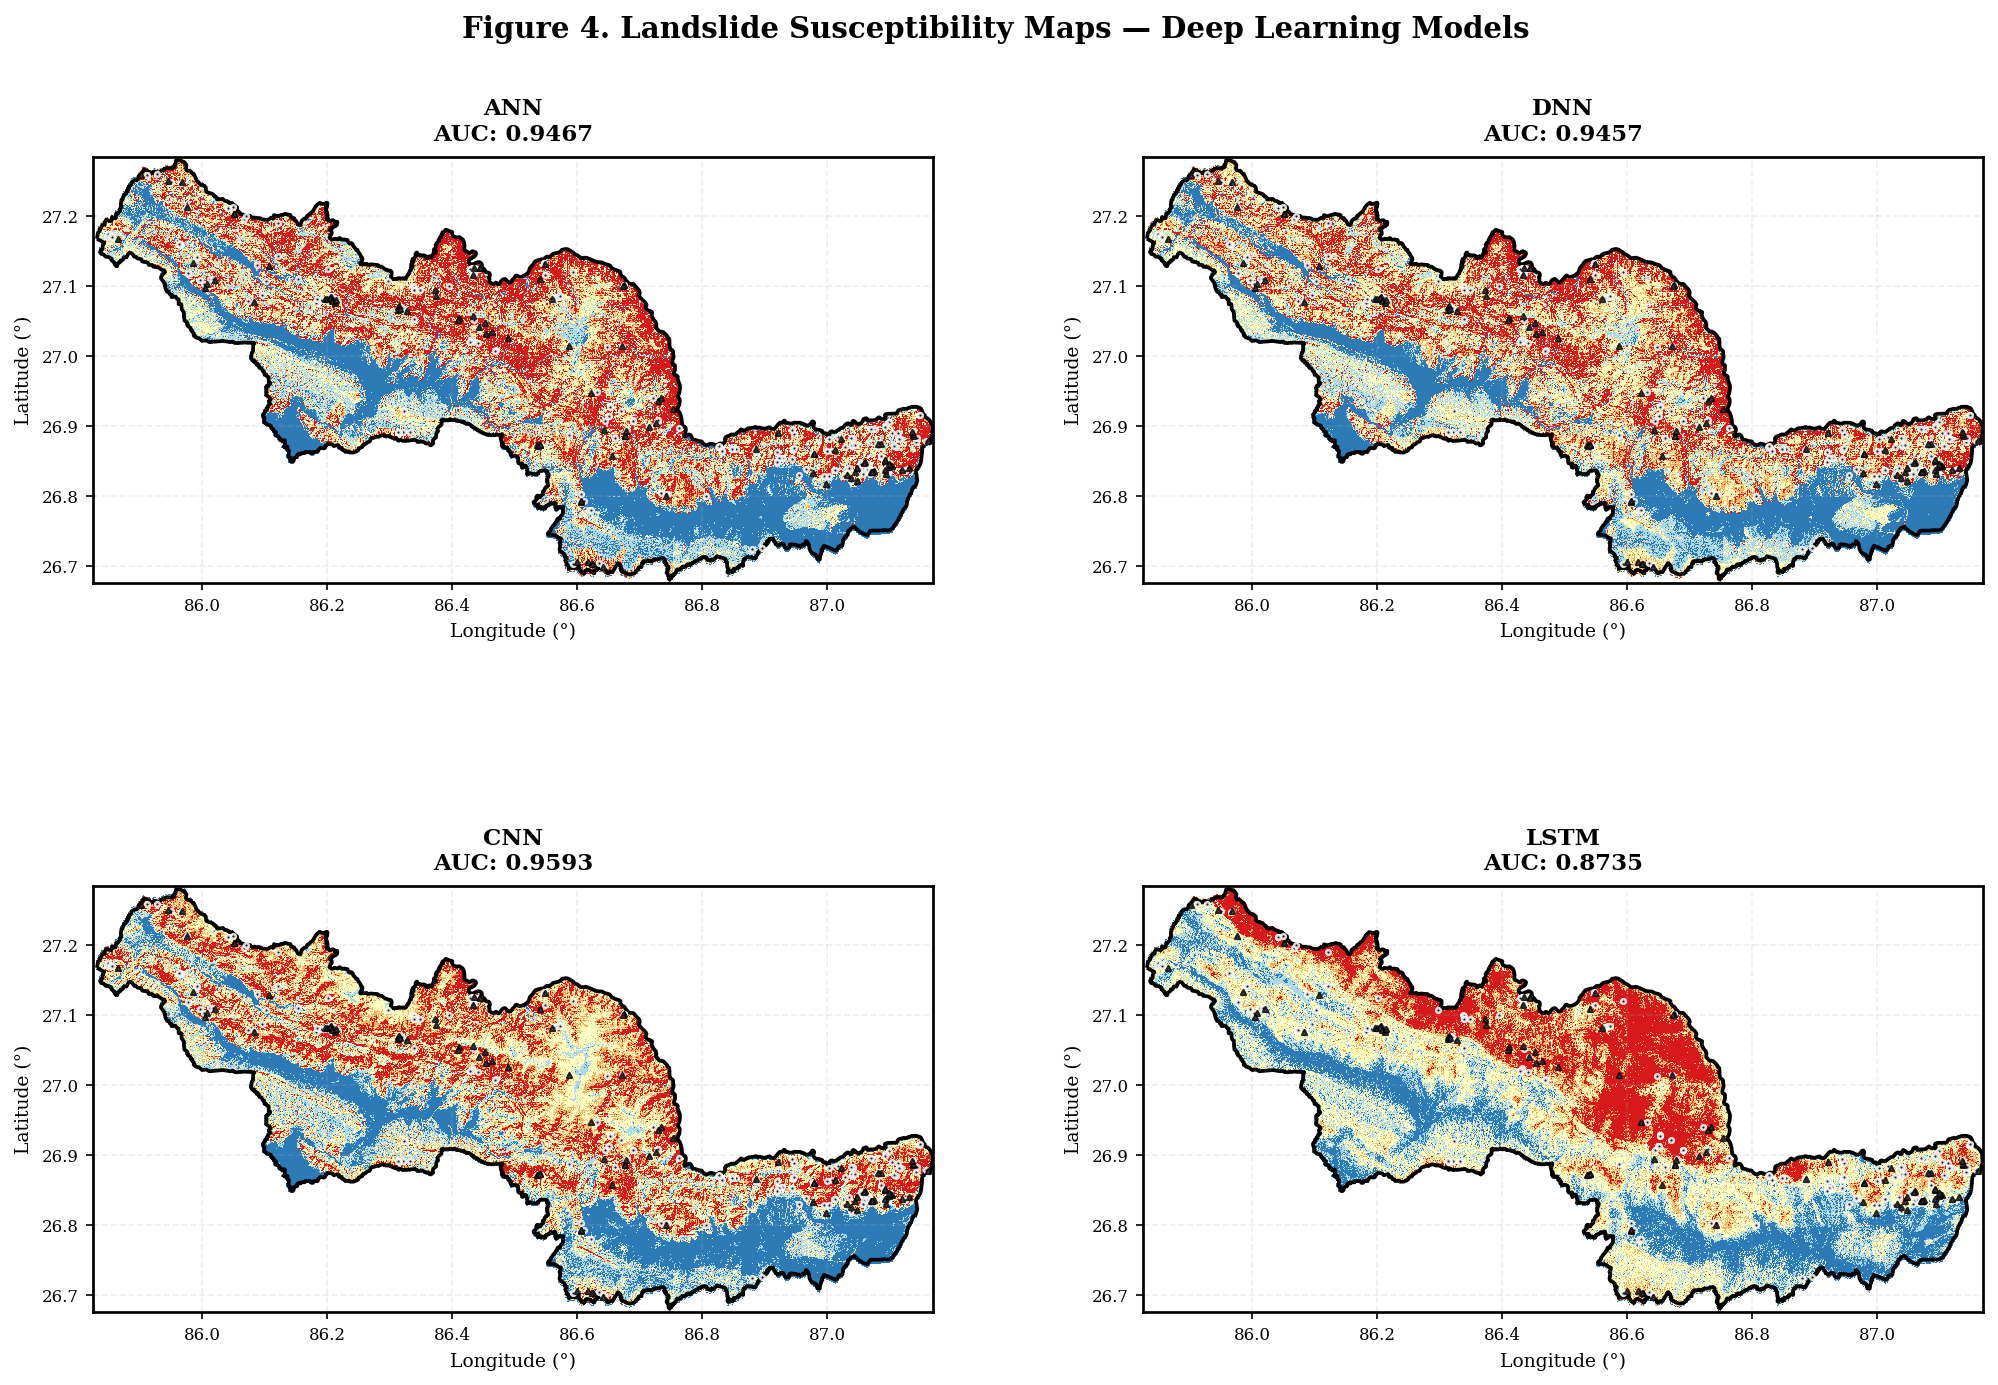

✓ DL maps figure saved.


In [ ]:
# ============================================================================
# SECTION 8 — DL MAPS & PERFORMANCE TABLE
# ============================================================================
print("\n" + "="*70)
print("  SECTION 8: DL MODELS — MAPS & PERFORMANCE")
print("="*70)

dl_names = list(dl_trained.keys())
dl_perf_df = pd.DataFrame([dl_results[m] for m in dl_names])
dl_perf_df = dl_perf_df[['Model','Test_AUC','Test_Accuracy','Precision','Recall','F1_Score']]

fig_dt, ax_dt = plt.subplots(figsize=(12, 2.8), facecolor='white')
ax_dt.axis('off')
cell_data_dl = [[r['Model'], f"{r['Test_AUC']:.4f}", f"{r['Test_Accuracy']:.4f}",
                 f"{r['Precision']:.4f}", f"{r['Recall']:.4f}", f"{r['F1_Score']:.4f}"]
                for _, r in dl_perf_df.iterrows()]
tbl2 = ax_dt.table(cellText=cell_data_dl, colLabels=col_labels,
                    cellLoc='center', loc='center')
tbl2.auto_set_font_size(False); tbl2.set_fontsize(11)
tbl2.scale(1, 2.0)
for (r,c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor('#d73027'); cell.set_text_props(color='white', weight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#fef0ee')
    cell.set_edgecolor('#cccccc'); cell.set_linewidth(0.5)
ax_dt.set_title('Table 2. Performance Metrics — Deep Learning Models\n'
                '(Independent Test Dataset)',
                fontsize=13, fontweight='bold', pad=15)
plt.savefig(os.path.join(OUTPUT_PATH,'Table2_DL_Performance.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

# DL Maps (2×2)
fig_dl = plt.figure(figsize=(14, 10), facecolor='white')
gs_dl  = fig_dl.add_gridspec(2, 2, hspace=0.30, wspace=0.25,
                               left=0.07, right=0.97, top=0.93, bottom=0.07)
for idx, name in enumerate(dl_names):
    r, c = divmod(idx, 2)
    ax = fig_dl.add_subplot(gs_dl[r, c])
    auc = dl_results[name]['Test_AUC']
    plot_susc_map(ax, susc_maps[name], name, auc=auc)

plt.suptitle('Figure 4. Landslide Susceptibility Maps — Deep Learning Models',
             fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_PATH,'Fig4_DL_Susceptibility_Maps.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ DL maps figure saved.")


  SECTION 9: COMPREHENSIVE MODEL COMPARISON


NameError: name 'dl_names' is not defined

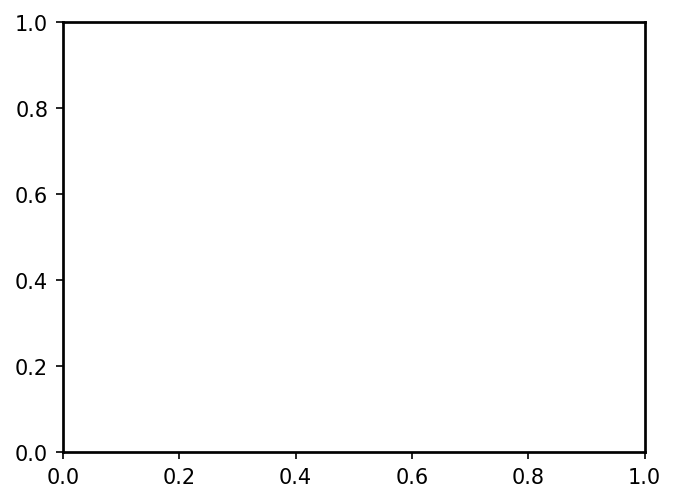

In [ ]:
# ============================================================================
# SECTION 9 — COMPREHENSIVE MODEL COMPARISON
# ============================================================================
print("\n" + "="*70)
print("  SECTION 9: COMPREHENSIVE MODEL COMPARISON")
print("="*70)

all_model_names  = list(ml_models.keys()) + list(dl_trained.keys())
all_model_probs  = {**ml_probs, **dl_probs}
all_model_roc    = {**ml_roc, **dl_roc}

# ─ Full ranking table ─────────────────────────────────────────────────────────
comp_df = pd.DataFrame(ml_results_list + dl_results_list).sort_values(
    'Test_AUC', ascending=False).reset_index(drop=True)
comp_df['Rank'] = comp_df.index + 1

fig_comp = plt.figure(figsize=(10, 8), facecolor='white')
gs_comp  = fig_comp.add_gridspec(2, 2, hspace=0.40, wspace=0.32,
                                  left=0.07, right=0.97, top=0.93, bottom=0.07)

# Panel A: Ranked AUC bar ──────────────────────────────────────────────────────
ax_rank = fig_comp.add_subplot(gs_comp[0, 0])
bar_col = ['#d73027' if r['Model'] in dl_names else '#2c7bb6'
           for _, r in comp_df.iterrows()]
bars = ax_rank.barh(comp_df['Model'][::-1], comp_df['Test_AUC'][::-1],
                    color=bar_col[::-1], edgecolor='black', linewidth=0.8)
for bar, auc in zip(bars[::-1], comp_df['Test_AUC']):
    ax_rank.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{auc:.4f}', va='center', fontsize=9.5)
ax_rank.axvline(0.9, color='green',  linestyle='--', linewidth=1.5, alpha=0.7, label='AUC=0.90')
ax_rank.axvline(0.8, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='AUC=0.80')
ax_rank.set_xlim(0.3, 1.05)
ax_rank.set_xlabel('Test AUC', fontsize=11)
ax_rank.set_title('(a) Model Ranking by Test AUC', fontsize=12, fontweight='bold', pad=10)
ml_patch = Patch(color='#2c7bb6', label='ML Models')
dl_patch = Patch(color='#d73027', label='DL Models')
ax_rank.legend(handles=[ml_patch, dl_patch]+ax_rank.get_legend_handles_labels()[0][2:],
               fontsize=9, loc='lower right')
ax_rank.grid(axis='x', alpha=0.3)

# Panel B: Multi-metric comparison ────────────────────────────────────────────
ax_met = fig_comp.add_subplot(gs_comp[0, 1])
metrics_to_plot = ['Test_AUC','Test_Accuracy','Precision','Recall','F1_Score']
x_pos = np.arange(len(comp_df))
colors_met = ['#2c7bb6','#fc8d59','#ffffbf','#1a9850','#d73027']
w_met = 0.15
for i, met in enumerate(metrics_to_plot):
    ax_met.bar(x_pos + i*w_met, comp_df[met], w_met, label=met,
               color=colors_met[i], edgecolor='black', linewidth=0.6, alpha=0.85)
ax_met.set_xticks(x_pos + 2*w_met)
ax_met.set_xticklabels(comp_df['Model'], rotation=40, ha='right', fontsize=9)
ax_met.set_ylabel('Score', fontsize=11)
ax_met.set_ylim(0, 1.18)
ax_met.set_title('(b) Multi-Metric Comparison', fontsize=12, fontweight='bold', pad=10)
ax_met.legend(fontsize=9, ncol=2, loc='upper right')
ax_met.grid(axis='y', alpha=0.3)

# Panel C: ROC Curves — ML ────────────────────────────────────────────────────
ax_roc_ml = fig_comp.add_subplot(gs_comp[1, 0])
roc_colors_ml = plt.cm.Blues(np.linspace(0.45, 0.95, len(ml_names)))
for i, name in enumerate(ml_names):
    fpr, tpr = ml_roc[name]
    auc = ml_results[name]['Test_AUC']
    ax_roc_ml.plot(fpr, tpr, linewidth=2.0, color=roc_colors_ml[i],
                   label=f'{name} (AUC={auc:.3f})')
ax_roc_ml.plot([0,1],[0,1],'k--', linewidth=1.2, label='Random (AUC=0.500)')
ax_roc_ml.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax_roc_ml.set_xlabel('False Positive Rate', fontsize=11)
ax_roc_ml.set_ylabel('True Positive Rate', fontsize=11)
ax_roc_ml.set_title('(c) ROC Curves — Machine Learning Models',
                    fontsize=12, fontweight='bold', pad=10)
ax_roc_ml.legend(fontsize=9, loc='lower right')
ax_roc_ml.grid(alpha=0.3)
ax_roc_ml.set_xlim(0,1); ax_roc_ml.set_ylim(0,1)

# Panel D: ROC Curves — DL ────────────────────────────────────────────────────
ax_roc_dl = fig_comp.add_subplot(gs_comp[1, 1])
roc_colors_dl = plt.cm.Reds(np.linspace(0.45, 0.90, len(dl_names)))
for i, name in enumerate(dl_names):
    fpr, tpr = dl_roc[name]
    auc = dl_results[name]['Test_AUC']
    ax_roc_dl.plot(fpr, tpr, linewidth=2.0, color=roc_colors_dl[i],
                   label=f'{name} (AUC={auc:.3f})')
ax_roc_dl.plot([0,1],[0,1],'k--', linewidth=1.2, label='Random (AUC=0.500)')
ax_roc_dl.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax_roc_dl.set_xlabel('False Positive Rate', fontsize=11)
ax_roc_dl.set_ylabel('True Positive Rate', fontsize=11)
ax_roc_dl.set_title('(d) ROC Curves — Deep Learning Models',
                    fontsize=12, fontweight='bold', pad=10)
ax_roc_dl.legend(fontsize=9, loc='lower right')
ax_roc_dl.grid(alpha=0.3)
ax_roc_dl.set_xlim(0,1); ax_roc_dl.set_ylim(0,1)

plt.suptitle('Figure 5. Comprehensive Model Comparison',
             fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_PATH,'Fig5_Comprehensive_Comparison.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Comprehensive comparison figure saved.")

# ─ Combined ROC (all models, one panel) ──────────────────────────────────────
fig_roc, ax_roc = plt.subplots(figsize=(6, 5), facecolor='white')
all_roc_sorted = sorted(all_model_probs.keys(),
                        key=lambda m: roc_auc_score(y_test, all_model_probs[m]),
                        reverse=True)
palette = plt.cm.tab10(np.linspace(0, 0.9, len(all_roc_sorted)))
for i, name in enumerate(all_roc_sorted):
    fpr, tpr = all_model_roc[name]
    auc = roc_auc_score(y_test, all_model_probs[name])
    ls = '-' if name in ml_names else '--'
    ax_roc.plot(fpr, tpr, linewidth=2.0, color=palette[i],
                linestyle=ls, label=f'{name} ({auc:.3f})')
ax_roc.plot([0,1],[0,1],'k:', linewidth=1.5, label='Random (0.500)')
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('ROC Curves — All ML & DL Models', fontsize=13, fontweight='bold', pad=12)
ax_roc.legend(fontsize=8.5, loc='lower right', ncol=1,
              frameon=True, edgecolor='black')
ax_roc.grid(alpha=0.3)
ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1)
for sp in ax_roc.spines.values(): sp.set_linewidth(1.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'Fig5b_ROC_All_Models.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

# ─ Confusion Matrices (best ML + best DL) ────────────────────────────────────
best_ml_name = max(ml_results, key=lambda m: ml_results[m]['Test_AUC'])
best_dl_name = max(dl_results, key=lambda m: dl_results[m]['Test_AUC'])

fig_cm, axes_cm = plt.subplots(1, 2, figsize=(6, 3.5), facecolor='white')
for ax_cm, name, probs_dict in zip(axes_cm,
                                    [best_ml_name, best_dl_name],
                                    [ml_probs, dl_probs]):
    yp = (probs_dict[name] > 0.5).astype(int)
    cm = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Landslide','Landslide'])
    disp.plot(ax=ax_cm, cmap='Blues', colorbar=False)
    ax_cm.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold', pad=10)
    ax_cm.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,'Fig5c_Confusion_Matrices.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()


  SECTION 10: ENSEMBLE MODELS — PERFORMANCE & MAPS

  Ensemble vs Top Individual Models:
        Model  Test_AUC  Test_Accuracy  Precision   Recall  F1_Score
  Ensemble_ML  0.966621       0.900000   0.896226 0.904762  0.900474
Ensemble_Top3  0.964626       0.900000   0.903846 0.895238  0.899522
Random Forest  0.964354       0.895238   0.902913 0.885714  0.894231
 Ensemble_All  0.963991       0.890476   0.886792 0.895238  0.890995
      XGBoost  0.963265       0.890476   0.886792 0.895238  0.890995
     LightGBM  0.960816       0.880952   0.884615 0.876190  0.880383
  Ensemble_DL  0.954921       0.900000   0.881818 0.923810  0.902326


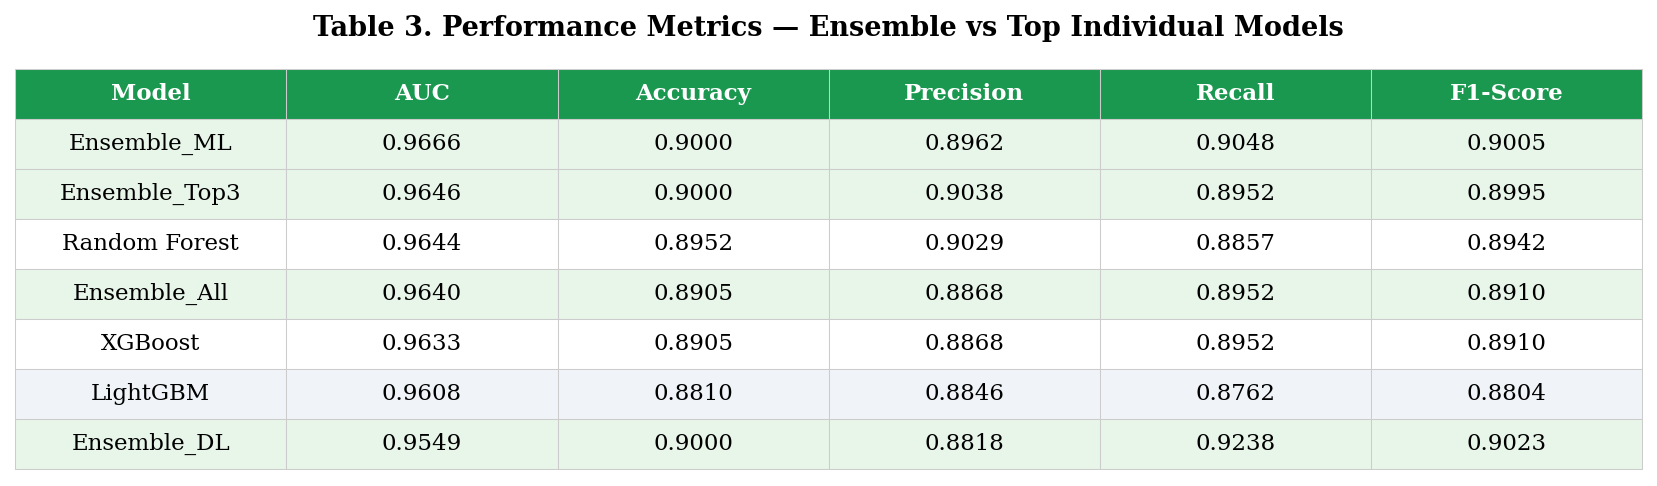

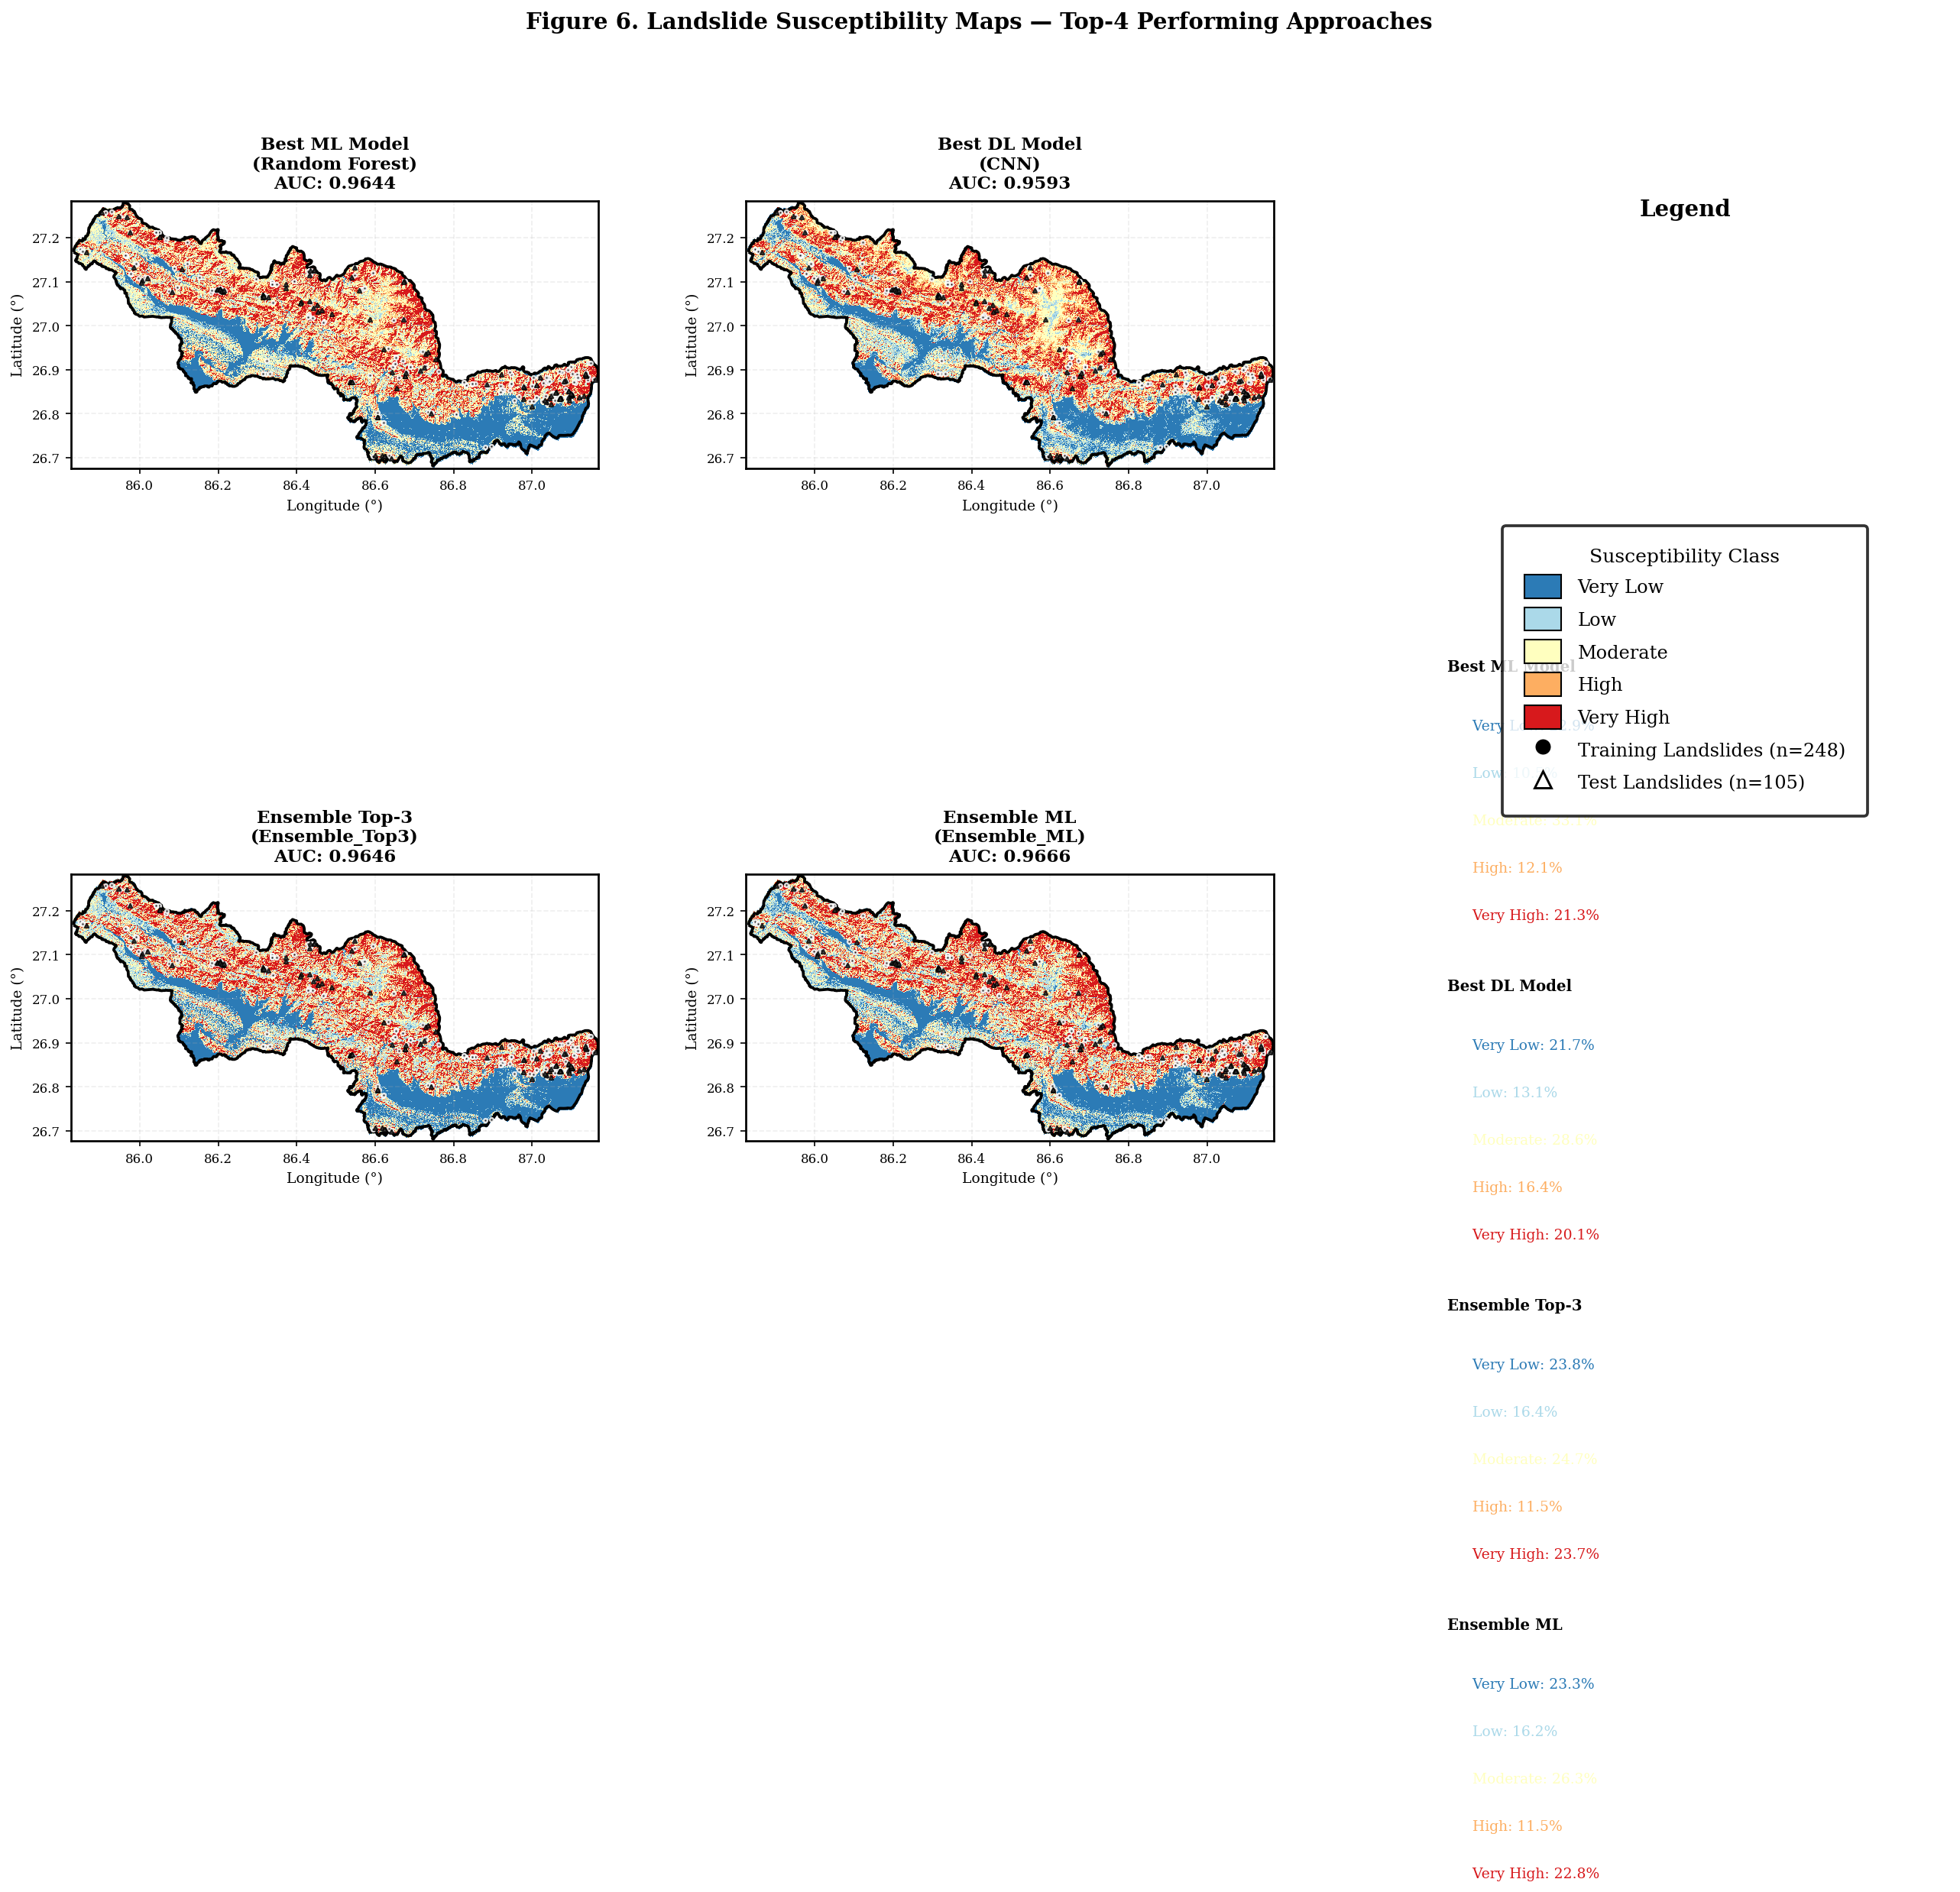

✓ Top-4 ensemble maps figure saved.


In [ ]:
# ============================================================================
# SECTION 10 — ENSEMBLE MODEL PERFORMANCE & MAPS
# ============================================================================
print("\n" + "="*70)
print("  SECTION 10: ENSEMBLE MODELS — PERFORMANCE & MAPS")
print("="*70)

# Define ensemble model names
ens_names = ['Ensemble_Top3','Ensemble_ML','Ensemble_DL','Ensemble_All']

# Initialize list to store performance metrics for ensemble models
ensemble_results = []

# --- Calculate performance for ensemble models ---
# all_model_probs and all_model_roc are already populated with individual model data from Section 9
# full_metrics function is available from Section 4
# y_test is available from Section 2

for name in ens_names:
    # Determine the constituent models for each ensemble type
    if name == 'Ensemble_Top3':
        constituent_models = top3_names_ens # top3_names_ens is defined in Section 6
    elif name == 'Ensemble_ML':
        constituent_models = all_ml_names   # all_ml_names is defined in Section 6
    elif name == 'Ensemble_DL':
        constituent_models = all_dl_names   # all_dl_names is defined in Section 6
    elif name == 'Ensemble_All':
        constituent_models = all_model_names # all_model_names is defined in Section 6
    else:
        print(f"Error: Unknown ensemble type {name}")
        continue

    # Get probabilities for constituent models from all_model_probs
    # This ensures we are averaging the *test set probabilities*.
    valid_constituent_probs = [all_model_probs[m] for m in constituent_models if m in all_model_probs]

    if len(valid_constituent_probs) > 0:
        y_prob_ensemble = np.nanmean(valid_constituent_probs, axis=0) # Calculate average probability
        metrics, _, (fpr, tpr) = full_metrics(name, y_test, y_prob_ensemble)
        ensemble_results.append(metrics)

        # Update global dictionaries with ensemble model probabilities and ROC curves
        all_model_probs[name] = y_prob_ensemble
        all_model_roc[name] = (fpr, tpr)
    else:
        print(f"Warning: No valid constituent model probabilities found for {name}. Skipping metric calculation.")

# Create DataFrame for ensemble results
ens_df = pd.DataFrame(ensemble_results)
# Sort by Test_AUC if ens_df is not empty
if not ens_df.empty:
    ens_df = ens_df.sort_values('Test_AUC', ascending=False).reset_index(drop=True)

# comp_df was created in Section 9 and contains all individual model results (ml_results_list + dl_results_list)
top_ind = comp_df.head(3).copy() # Get top 3 individual models

# Create a comparison DataFrame combining top individual models and ensemble models
compare_df = pd.concat([top_ind, ens_df], ignore_index=True)
compare_df = compare_df.sort_values('Test_AUC', ascending=False).reset_index(drop=True)
compare_df['Rank'] = compare_df.index + 1


print("\n  Ensemble vs Top Individual Models:")
# col_labels is defined in Section 7, so it's available.
print(compare_df[['Model','Test_AUC','Test_Accuracy','Precision','Recall','F1_Score']].to_string(index=False))

# ─ Ensemble Performance Table ────────────────────────────────────────────────
fig_et, ax_et = plt.subplots(figsize=(14, 3.5), facecolor='white')
ax_et.axis('off')
cell_ens = [[r['Model'], f"{r['Test_AUC']:.4f}", f"{r['Test_Accuracy']:.4f}",
             f"{r['Precision']:.4f}", f"{r['Recall']:.4f}", f"{r['F1_Score']:.4f}"]
            for _, r in compare_df.iterrows()]
tbl_e = ax_et.table(cellText=cell_ens, colLabels=col_labels,
                     cellLoc='center', loc='center')
tbl_e.auto_set_font_size(False); tbl_e.set_fontsize(11)
tbl_e.scale(1, 2.0)
for (r, c), cell in tbl_e.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a9850'); cell.set_text_props(color='white', weight='bold')
    # Use compare_df.iloc[r-1] to access the row in compare_df for styling
    elif compare_df.iloc[r-1]['Model'].startswith('Ensemble'):
        cell.set_facecolor('#e8f5e9')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('#cccccc'); cell.set_linewidth(0.5)
ax_et.set_title('Table 3. Performance Metrics — Ensemble vs Top Individual Models',
                fontsize=13, fontweight='bold', pad=15)
plt.savefig(os.path.join(OUTPUT_PATH,'Table3_Ensemble_Performance.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

# ─ Top-4 Susceptibility Maps for Publication ────────────────────────────────
best_ml = max(ml_results, key=lambda m: ml_results[m]['Test_AUC'])
best_dl = max(dl_results, key=lambda m: dl_results[m]['Test_AUC'])
top4    = [best_ml, best_dl, 'Ensemble_Top3', 'Ensemble_ML']
top4_labels = ['Best ML Model', 'Best DL Model', 'Ensemble Top-3', 'Ensemble ML']

fig_top4 = plt.figure(figsize=(18, 12), facecolor='white')
gs_t4    = fig_top4.add_gridspec(2, 3, hspace=0.32, wspace=0.28,
                                  left=0.06, right=0.97, top=0.93, bottom=0.07)

# auc_lookup needs to include ensemble models now
auc_lookup = {**{m: ml_results[m]['Test_AUC'] for m in ml_results},
              **{m: dl_results[m]['Test_AUC'] for m in dl_results},
              **{r['Model']: r['Test_AUC'] for r in ensemble_results}} # use ensemble_results list

for idx, (mname, mlabel) in enumerate(zip(top4, top4_labels)):
    # This assigns map panels in a 2x2 grid, leaving the 3rd column for the legend.
    ax = fig_top4.add_subplot(gs_t4[idx//2, idx%2])
    auc = auc_lookup.get(mname, 0)
    # FIX: plot_map should be plot_susc_map. Also remove `classified=True` argument.
    plot_susc_map(ax, susc_maps[mname], f'{mlabel}\n({mname})', auc=auc)

# Legend (This part seems correctly placed in the 3rd column)
ax_leg2 = fig_top4.add_subplot(gs_t4[:, 2])
ax_leg2.axis('off')
patches2 = [Patch(facecolor=SUSC_COLORS[i], edgecolor='black', linewidth=1.0,
                  label=SUSC_LABELS[i]) for i in range(5)]
markers2 = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
           markersize=11, markeredgecolor='white', markeredgewidth=1.4,
           label=f'Training Landslides (n={len(train_gdf)})', linestyle='None'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='white',
           markersize=11, markeredgecolor='black', markeredgewidth=1.4,
           label=f'Test Landslides (n={len(test_gdf)})', linestyle='None'),
]
leg2 = ax_leg2.legend(handles=patches2+markers2, loc='center', fontsize=11.5,
                      frameon=True, edgecolor='black', ncol=1,
                      title='Susceptibility Class', title_fontsize=12,
                      borderpad=1.2, handletextpad=0.9, handleheight=1.6)
leg2.get_frame().set_linewidth(1.8)
ax_leg2.text(0.5, 0.90, 'Legend', transform=ax_leg2.transAxes,
             fontsize=14, fontweight='bold', ha='center', va='top')

# Area distribution bar for each map
y_leg = 0.50
for mname, mlabel in zip(top4, top4_labels):
    cl, _ = classify_nb(susc_maps[mname])
    total = np.sum(~np.isnan(cl))
    pcts  = [np.sum(cl == i)/total*100 for i in range(5)]
    ax_leg2.text(0.05, y_leg, mlabel, transform=ax_leg2.transAxes,
                 fontsize=9.5, fontweight='bold')
    y_leg -= 0.05
    for i, (lbl, pct) in enumerate(zip(SUSC_LABELS, pcts)):
        ax_leg2.text(0.08, y_leg, f'  {lbl}: {pct:.1f}%',
                     transform=ax_leg2.transAxes, fontsize=9,
                     color=SUSC_COLORS[i])
        y_leg -= 0.04
    y_leg -= 0.02

plt.suptitle('Figure 6. Landslide Susceptibility Maps — Top-4 Performing Approaches',
             fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_PATH,'Fig6_Top4_Susceptibility_Maps.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Top-4 ensemble maps figure saved.")

In [ ]:
# ============================================================================
# SECTION 11 — RELIABILITY: MAE, RMSE, COMPOUND FACTOR
# ============================================================================
print("\n" + "="*70)
print("  SECTION 11: RELIABILITY ANALYSIS & COMPOUND FACTOR")
print("="*70)

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Helper function to extract values from a susceptibility map at test points
def extract_at_test_points(susc_map):
    # test_data (DataFrame) and transform (Affine object) are available globally
    # from previous cells (Section 2 and Section 6 respectively)

    test_xs = test_data['x'].values
    test_ys = test_data['y'].values

    extracted_values = np.full(len(test_xs), np.nan, dtype=np.float32)

    # Get the inverse transform for world to pixel coordinates
    inv_transform = ~transform

    rows, cols = susc_map.shape

    for i, (x, y) in enumerate(zip(test_xs, test_ys)):
        # Convert world coordinates to pixel coordinates
        row_float, col_float = inv_transform * (x, y)
        row, col = int(row_float), int(col_float)

        # Check if coordinates are within the map bounds
        if 0 <= row < rows and 0 <= col < cols:
            val = susc_map[row, col]
            extracted_values[i] = val
        # If outside bounds or NaN already, it remains np.nan

    return extracted_values


# Collect all predictions at test points
all_test_probs = {**ml_probs, **dl_probs}
for ens in ens_names:
    all_test_probs[ens] = extract_at_test_points(susc_maps[ens])

# Combine all results
all_metrics_list = (ml_results_list + dl_results_list + ensemble_results)
all_metrics_df   = pd.DataFrame(all_metrics_list)

# MAE & RMSE
for name in all_test_probs:
    yp = all_test_probs[name]

    # Filter out NaN values from y_test and yp consistently
    valid_indices = ~np.isnan(yp)
    y_test_filtered = y_test[valid_indices]
    yp_filtered = yp[valid_indices]

    # Only calculate if there are valid points remaining
    if len(yp_filtered) > 0:
        mae  = mean_absolute_error(y_test_filtered, yp_filtered)
        rmse = np.sqrt(mean_squared_error(y_test_filtered, yp_filtered))
        mask = all_metrics_df['Model'] == name
        if mask.any():
            all_metrics_df.loc[mask, 'MAE']  = mae
            all_metrics_df.loc[mask, 'RMSE'] = rmse
    else:
        print(f"Warning: No valid predictions for {name} to calculate MAE/RMSE.")

# Compound Factor: CF = 0.5*AUC + 0.3*F1 + 0.2*(1-RMSE)
# Ensure RMSE is not NaN before calculation
all_metrics_df['CF'] = (0.5 * all_metrics_df['Test_AUC'] +
                        0.3 * all_metrics_df['F1_Score']  +
                        0.2 * (1 - all_metrics_df['RMSE'].fillna(1)))
all_metrics_df = all_metrics_df.sort_values('CF', ascending=False).reset_index(drop=True)
all_metrics_df['CF_Rank'] = all_metrics_df.index + 1

print("\n  Final Model Ranking (Compound Factor = 0.5·AUC + 0.3·F1 + 0.2·(1-RMSE)):")
print(all_metrics_df[['Model','Test_AUC','F1_Score','MAE','RMSE','CF','CF_Rank']].to_string(index=False))

# ─ Compound Factor Chart ──────────────────────────────────────────────────────
fig_cf = plt.figure(figsize=(16, 7), facecolor='white')
gs_cf  = fig_cf.add_gridspec(1, 2, wspace=0.35, left=0.06, right=0.97,
                              top=0.90, bottom=0.10)

ax_cf1 = fig_cf.add_subplot(gs_cf[0])
cf_colors = ['#1a9850' if n.startswith('Ensemble') else
             '#d73027' if n in dl_names else '#2c7bb6'
             for n in all_metrics_df['Model']]
bars_cf = ax_cf1.barh(all_metrics_df['Model'][::-1],
                      all_metrics_df['CF'][::-1],
                      color=cf_colors[::-1], edgecolor='black', linewidth=0.8)
for bar, v in zip(bars_cf[::-1], all_metrics_df['CF']):
    ax_cf1.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9.5)
ax_cf1.set_xlabel('Compound Factor (CF)', fontsize=11)
ax_cf1.set_title('(a) Model Prioritisation — Compound Factor', fontsize=12, fontweight='bold', pad=10)
ml_p  = Patch(color='#2c7bb6',  label='ML Models')
dl_p  = Patch(color='#d73027',  label='DL Models')
ens_p = Patch(color='#1a9850',  label='Ensemble Models')
ax_cf1.legend(handles=[ml_p, dl_p, ens_p], fontsize=10)
ax_cf1.grid(axis='x', alpha=0.3)

ax_cf2 = fig_cf.add_subplot(gs_cf[1])
rmse_order = all_metrics_df.sort_values('RMSE')
bar_col2 = ['#1a9850' if n.startswith('Ensemble') else
            '#d73027' if n in dl_names else '#2c7bb6'
            for n in rmse_order['Model']]
ax_cf2.barh(rmse_order['Model'], rmse_order['MAE'],
            color=bar_col2, edgecolor='black', linewidth=0.7,
            alpha=0.7, label='MAE', height=0.35)
ax_cf2.barh([n+' ' for n in rmse_order['Model']], rmse_order['RMSE'],
            color=bar_col2, edgecolor='black', linewidth=0.7,
            alpha=0.45, label='RMSE', height=0.35)
ax_cf2.set_xlabel('Error Value', fontsize=11)
ax_cf2.set_title('(b) MAE & RMSE Comparison', fontsize=12, fontweight='bold', pad=10)
ax_cf2.legend(fontsize=10)
ax_cf2.grid(axis='x', alpha=0.3)

plt.suptitle('Figure 7. Reliability Analysis & Model Prioritisation',
             fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_PATH,'Fig7_Reliability_CompoundFactor.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Reliability figure saved.")


  SECTION 11: RELIABILITY ANALYSIS & COMPOUND FACTOR


NameError: name 'ens_names' is not defined

In [ ]:
# ============================================================================
# SECTION 12 — SAVE ALL RESULTS
# ============================================================================
print("\n" + "="*70)
print("  SECTION 12: SAVING RESULTS")
print("="*70)

all_metrics_df.to_csv(os.path.join(OUTPUT_PATH,'Results_AllModels_Comprehensive.csv'), index=False)
vif_data.to_csv(os.path.join(OUTPUT_PATH,'Results_VIF_Analysis.csv'), index=False)

print(f"✓ CSV results saved to {OUTPUT_PATH}")
print(f"✓ Total susceptibility maps: {len(susc_maps)}")


  SECTION 12: SAVING RESULTS


NameError: name 'all_metrics_df' is not defined

In [ ]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("  ANALYSIS COMPLETE — SUMMARY")
print("="*70)
best_overall = all_metrics_df.iloc[0]
print(f"\n  🏆 Best Model (Compound Factor): {best_overall['Model']}")
print(f"     AUC  = {best_overall['Test_AUC']:.4f}")
print(f"     F1   = {best_overall['F1_Score']:.4f}")
print(f"     RMSE = {best_overall['RMSE']:.4f}")
print(f"     CF   = {best_overall['CF']:.4f}")
print(f"\n  📂 All outputs saved to: {OUTPUT_PATH}")
print(f"\n  📊 Figures generated:")
for fname in sorted(os.listdir(OUTPUT_PATH)):
    if fname.endswith('.png'):
        print(f"     • {fname}")
print("\n" + "="*70)


  ANALYSIS COMPLETE — SUMMARY

  🏆 Best Model (Compound Factor): Random Forest
     AUC  = 0.9644
     F1   = 0.8942
     RMSE = 0.2650
     CF   = 0.8975

  📂 All outputs saved to: /content/drive/MyDrive/lsm_us/

  📊 Figures generated:
     • Fig1_Multicollinearity_Analysis.png
     • Fig3_ML_Susceptibility_Maps.png
     • Fig4_DL_Susceptibility_Maps.png
     • Fig5_Comprehensive_Comparison.png
     • Fig5b_ROC_All_Models.png
     • Fig5c_Confusion_Matrices.png
     • Fig6_Top4_Susceptibility_Maps.png
     • Fig7_Reliability_CompoundFactor.png
     • Fig_Factor_Importance_Radar.png
     • Table1_ML_Performance.png
     • Table2_DL_Performance.png
     • Table3_Ensemble_Performance.png



## Spatial_Analysis_LGS_Areas

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio.mask
from rasterio.features import rasterize
from shapely.geometry import mapping
from rasterio.io import MemoryFile

# Assuming susc_maps, watershed, ref, transform, classify_nb, OUTPUT_PATH, SUSC_LABELS are available from previous cells

print("Calculating area of landslide susceptibility classes within each LGS...")

# 1. Calculate pixel area (in square meters)
pixel_width = abs(ref.transform.a)
pixel_height = abs(ref.transform.e)
pixel_area_sq_m = pixel_width * pixel_height
pixel_area_sq_km = pixel_area_sq_m / 1_000_000
print(f"  Single pixel area: {pixel_area_sq_km:.4f} km²")

results_list = []

# Get a list of models that were part of the reliability analysis
models_for_analysis = all_metrics_df['Model'].tolist()

# Ensure watershed has an 'id' column for identification, or create one
if 'id' not in watershed.columns:
    watershed['id'] = range(len(watershed)) # Simple ID if not present

# Iterate through each model
for model_name in models_for_analysis:
    if model_name not in susc_maps:
        print(f"  Skipping model '{model_name}': Susceptibility map not found.")
        continue

    print(f"\nProcessing model: {model_name}")
    susc_map_array = susc_maps[model_name]

    # Iterate through each LGS (watershed polygon)
    for index, lgs_row in watershed.iterrows():
        lgs_id = lgs_row['id']
        lgs_geom = lgs_row.geometry

        # Reproject LGS geometry to the CRS of the raster
        # Wrap shapely geometry in a GeoSeries to use to_crs method
        lgs_geom_reprojected = gpd.GeoSeries([lgs_geom], crs=watershed.crs).to_crs(ref.crs).iloc[0]

        # Use a MemoryFile to create a temporary raster dataset from the NumPy array
        # This allows rasterio.mask.mask to operate on the susceptibility data
        with MemoryFile() as memfile:
            with memfile.open(driver='GTiff',
                              height=susc_map_array.shape[0],
                              width=susc_map_array.shape[1],
                              count=1,
                              dtype=susc_map_array.dtype,
                              crs=ref.crs, # Use ref's CRS
                              transform=ref.transform) as tmp_dataset:
                tmp_dataset.write(susc_map_array, 1)

                try:
                    clipped_susc_map_ma, _ = rasterio.mask.mask(
                        tmp_dataset, [mapping(lgs_geom_reprojected)], crop=True, filled=True, nodata=np.nan
                    )
                    clipped_susc_map = clipped_susc_map_ma[0] # Get the single band
                    # Ensure it's a plain NumPy array, not a MaskedArray, before any further processing
                    clipped_susc_map = np.asarray(clipped_susc_map)

                    # Explicitly replace NODATA_VALUE with np.nan for correct classification
                    # (though nodata=np.nan in mask should handle this)
                    clipped_susc_map[clipped_susc_map == NODATA_VALUE] = np.nan

                except ValueError as e:
                    # This can happen if the LGS polygon does not overlap the raster
                    print(f"    LGS {lgs_id} for model {model_name}: Skipping due to masking error - {e}")
                    continue

        # Filter out nodata values from the clipped map before classification
        valid_pixels = clipped_susc_map[~np.isnan(clipped_susc_map)]

        if valid_pixels.size == 0:
            print(f"    LGS {lgs_id} for model {model_name}: No valid susceptibility pixels found. Recording zero areas.")
            # Record zero areas if no valid pixels were found in this LGS
            row_data = {'Model': model_name, 'LGS_ID': lgs_id}
            areas_sq_km = {SUSC_LABELS[i]: 0.0 for i in range(5)}
            row_data.update(areas_sq_km)
            results_list.append(row_data)
            continue

        # Classify the valid susceptibility values
        classified_values, _ = classify_nb(clipped_susc_map)
        # Ensure classified_values is a plain NumPy array
        classified_values = np.asarray(classified_values)

        # Count pixels for each class within the LGS
        class_counts = {i: 0 for i in range(5)}
        # Filter out NaNs again, just in case, for np.unique
        unique, counts = np.unique(classified_values[~np.isnan(classified_values)], return_counts=True)
        for class_idx, count in zip(unique, counts):
            class_counts[int(class_idx)] = count

        # Convert counts to area (km²)
        areas_sq_km = {SUSC_LABELS[i]: count * pixel_area_sq_km for i, count in class_counts.items()}

        # Store results
        row_data = {'Model': model_name, 'LGS_ID': lgs_id}
        row_data.update(areas_sq_km)
        results_list.append(row_data)

print("\n✓ Area calculation complete.")

# Create DataFrame from results
lgs_areas_df = pd.DataFrame(results_list)

# Save to CSV
output_csv_path = os.path.join(OUTPUT_PATH, 'LGS_Susceptibility_Areas.csv')
lgs_areas_df.to_csv(output_csv_path, index=False)

print(f"✓ Results saved to: {output_csv_path}")
print("\n" + "="*70)
print("  Spatial Analysis Complete ")
print("="*70)

Calculating area of landslide susceptibility classes within each LGS...
  Single pixel area: 0.0009 km²

Processing model: Random Forest

Processing model: XGBoost

Processing model: LightGBM

Processing model: DNN

Processing model: ANN

Processing model: Logistic Regression

Processing model: SVM

Processing model: CNN

Processing model: Ensemble_ML

Processing model: Ensemble_All

Processing model: Ensemble_Top3

Processing model: Ensemble_DL

Processing model: LSTM

✓ Area calculation complete.
✓ Results saved to: /content/drive/MyDrive/lsm_us/LGS_Susceptibility_Areas.csv

  Spatial Analysis Complete 
